<a href="https://colab.research.google.com/github/JulTob/Modelling/blob/main/GLM/Julio_analisis_datos_p1_p5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OsteoRed
## Análisis científico de datos
> Caso 1   
> - Modelos lineales generalizados   
> - Equipo 07-Cox
> - _Julio Toboso · Análista de datos_

# 🏥 Proyecto 1 · OsteoRed · Análisis

Trabajamos con el banco del equipo 07-Cox.
- En `cohorte` hay una fila por mujer
- En `pp`, una por cada revisión en la que seguía en riesgo.

Endotipo y estadio se anotaron al inicio, también si después no hubo fractura.

El hilo es el standard: qué se pregunta, qué modelo encaja, cómo se comprueba y qué se puede decir con el resultado. Tratamiento y clínica se leen como asociaciones.



### Descarga automática de datos desde el repositorio de GitHub
Ejecuta esta celda para descargar `cohorte.rds` y `pp.rds` directamente del repositorio de GitHub `JulTob/Modelling`.

In [12]:
# URLs de descarga de los archivos de datos en formato RAW desde GitHub
urls <- list(
  "cohorte.rds" = "https://raw.githubusercontent.com/JulTob/Modelling/main/GLM/cohorte.rds",
  "pp.rds" = "https://raw.githubusercontent.com/JulTob/Modelling/main/GLM/pp.rds"
)

for (archivo in names(urls)) {
  if (!file.exists(archivo)) {
    message(paste("Descargando", archivo, "..."))
    tryCatch({
      download.file(urls[[archivo]], destfile = archivo, mode = "wb")
      message(paste(archivo, "descargado correctamente."))
    }, error = function(e) {
      message(paste("Error al descargar", archivo, ":", e$message))
    })
  } else {
    message(paste("El archivo", archivo, "ya existe en el directorio local."))
  }
}

El archivo cohorte.rds ya existe en el directorio local.

El archivo pp.rds ya existe en el directorio local.




## Preparación

La primera celda instala lo que falte.


In [13]:
paquetes <- c(
        "ggplot2", "dplyr", "tidyr", "lme4", "nnet",
        "ordinal", "pROC", "MASS", "DHARMa", "statmod",
        "detectseparation", "survival", "reformulas",
        "performance"
    )

disponibles <- vapply(
        paquetes,
        requireNamespace,
        logical( 1 ),
        quietly = TRUE
    )

if ( any( !disponibles ) ) {
    install.packages(
            paquetes[ !disponibles ],
            repos = "https://cloud.r-project.org"
        )
    }

suppressPackageStartupMessages({
        library( ggplot2 )
        library( dplyr )
        library( tidyr )
        library( lme4 )
        library( nnet )
        library( ordinal )
    })

options( width = 88 )



### Integridad de las dos tablas

Antes de ajustar miramos ausentes, la codificación y que los `id` cuadren.
En `pp`, cada mujer aporta tantas filas como su `tiempo`, y no hay
revisiones después de la fractura ni después de la censura.
Las que no se observaron **no se han imputado con ceros**.

El atributo del generador se guarda y no se imprime. La comparación
va al final, cuando los modelos ya están elegidos.



In [14]:
columnas_cohorte <- c(
        "id", "centro", "x1", "x2", "tiempo", "evento",
        "ever", "clase_nom", "sever_ord"
    )
columnas_pp <- c( "id", "centro", "x1", "x2", "periodo", "y" )

stopifnot(
        "Faltan columnas en cohorte." =
            all( columnas_cohorte %in% names( cohorte ) ),
        "Faltan columnas en pp." =
            all( columnas_pp %in% names( pp ) ),
        "Hay ausentes en cohorte: revisarlos antes de continuar." =
            !anyNA( cohorte[ columnas_cohorte ] ),
        "Hay ausentes en pp: revisarlos antes de continuar." =
            !anyNA( pp[ columnas_pp ] ),
        "id debe ser unico en cohorte." =
            !anyDuplicated( cohorte$id ),
        "Revisar indicadores binarios." =
            all( c( cohorte$x2, cohorte$ever, cohorte$evento, pp$y )
                %in% c( 0, 1 ) ),
        "ever y evento deben coincidir en este diseño." =
            all( cohorte$ever == cohorte$evento )
    )

cohorte$centro <- factor( cohorte$centro )
cohorte$clase_nom <- factor(
        cohorte$clase_nom,
        levels = c( "A", "B", "C" )
    )
cohorte$sever_ord <- ordered(
        cohorte$sever_ord,
        levels = c( "Leve", "Moderado", "Grave" )
    )
pp$centro <- factor( pp$centro )
pp$periodo <- factor(
        pp$periodo,
        levels = as.character( 1:6 )
    )
stopifnot( "Categorias inesperadas." = !anyNA( cohorte ),
           "Periodos inesperados." = !anyNA( pp ) )


In [15]:
pp <- pp |>
    arrange( id, periodo )
fila_paciente <- match( pp$id, cohorte$id )

stopifnot(
        "Hay pacientes de pp ausentes en cohorte." =
            !anyNA( fila_paciente ),
        "Duplicados id-periodo." =
            !anyDuplicated( pp[ c( "id", "periodo" ) ] ),
        "x1 no coincide entre tablas." =
            all( pp$x1 == cohorte$x1[ fila_paciente ] ),
        "x2 no coincide entre tablas." =
            all( pp$x2 == cohorte$x2[ fila_paciente ] ),
        "centro no coincide entre tablas." =
            all( pp$centro == cohorte$centro[ fila_paciente ] )
    )

control_pp <- pp |>
    group_by( id ) |>
    summarise(
            filas = n(),
            secuencia_correcta = all(
                    as.integer( as.character( periodo ) ) == seq_len( n() )
                ),
            eventos = sum( y ),
            evento_final = last( y ),
            .groups = "drop"
        ) |>
    left_join(
            cohorte[ c( "id", "tiempo", "evento" ) ],
            by = "id"
        )

stopifnot(
        "Faltan pacientes en pp." = nrow( control_pp ) == nrow( cohorte ),
        "Seguimiento incompleto o posterior a salida." =
            all( control_pp$filas == control_pp$tiempo ),
        "Hay saltos en los periodos." = all( control_pp$secuencia_correcta ),
        "Eventos inconsistentes." =
            all( control_pp$eventos == control_pp$evento ),
        "Hay revisiones posteriores al evento." =
            all( control_pp$evento_final == control_pp$evento )
    )
cat( "Integridad de cohorte y pp comprobada.\n" )


Integridad de cohorte y pp comprobada.


pacientes,centros,filas_persona_periodo,fracturas_observadas,censuradas,proporcion_evento_observado
<int>,<int>,<int>,<int>,<int>,<dbl>
803,24,3148,247,556,0.3075965


       id            centro          x1                 x2            tiempo    
 Min.   :  1.0   9      : 45   Min.   :-2.58876   Min.   :0.000   Min.   :1.00  
 1st Qu.:201.5   4      : 41   1st Qu.:-0.71356   1st Qu.:0.000   1st Qu.:3.00  
 Median :402.0   23     : 41   Median :-0.09956   Median :0.000   Median :4.00  
 Mean   :402.0   21     : 39   Mean   :-0.04108   Mean   :0.457   Mean   :3.92  
 3rd Qu.:602.5   6      : 38   3rd Qu.: 0.63322   3rd Qu.:1.000   3rd Qu.:5.00  
 Max.   :803.0   10     : 37   Max.   : 3.00876   Max.   :1.000   Max.   :6.00  
                 (Other):562                                                    
     evento            ever        clase_nom    sever_ord  
 Min.   :0.0000   Min.   :0.0000   A:354     Leve    :298  
 1st Qu.:0.0000   1st Qu.:0.0000   B:202     Moderado:234  
 Median :0.0000   Median :0.0000   C:247     Grave   :271  
 Mean   :0.3076   Mean   :0.3076                           
 3rd Qu.:1.0000   3rd Qu.:1.0000                    

,variable,clase_R,ausentes
,<chr>,<chr>,<int>
id,id,integer,0
centro,centro,factor,0
x1,x1,numeric,0
x2,x2,integer,0
tiempo,tiempo,integer,0
evento,evento,integer,0
ever,ever,integer,0
clase_nom,clase_nom,factor,0
sever_ord,sever_ord,ordered/factor,0


    limite_inferior limite_superior pacientes_fuera
25%       -2.733734        2.653397               2
     id centro       x1 x2 ever
266 266      9 2.742337  0    1
354 354     11 3.008763  0    1


x2,pacientes,fragilidad_media,fragilidad_sd,seguimiento_medio,eventos,proporcion_observada
<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
0,436,-0.003803492,1.0004529,3.830275,154,0.353211
1,367,-0.085361589,0.9375626,4.027248,93,0.253406


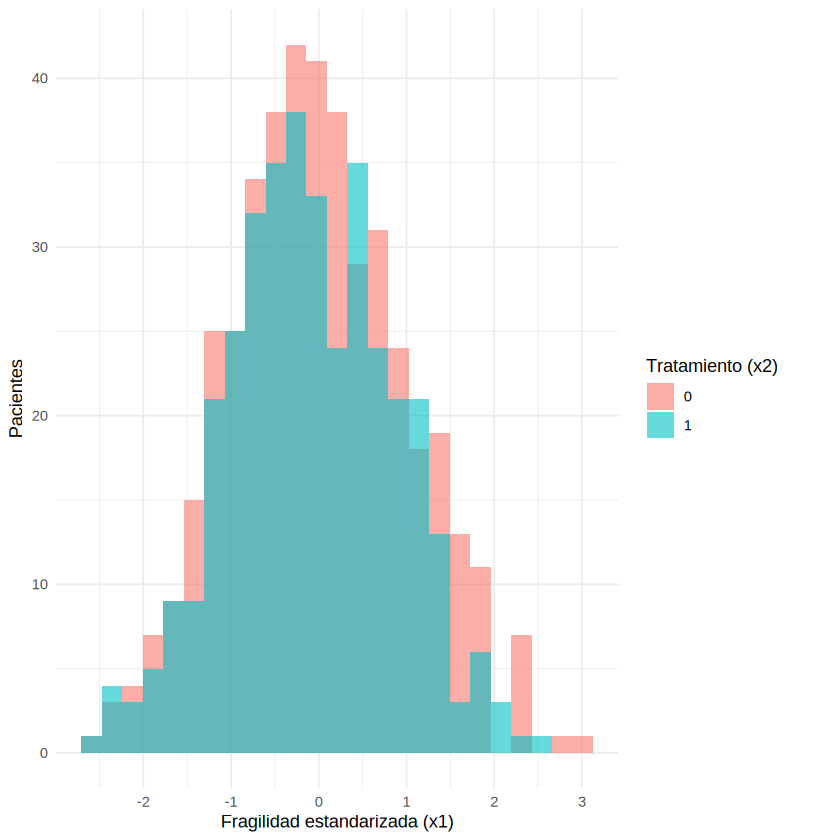

In [16]:
data.frame(
        pacientes = nrow( cohorte ),
        centros = nlevels( cohorte$centro ),
        filas_persona_periodo = nrow( pp ),
        fracturas_observadas = sum( cohorte$evento ),
        censuradas = sum( cohorte$evento == 0 ),
        proporcion_evento_observado = mean( cohorte$ever )
    )

summary( cohorte[ columnas_cohorte ] )

data.frame(
        variable = columnas_cohorte,
        clase_R = vapply(
                cohorte[ columnas_cohorte ],
                function( x ) paste( class( x ), collapse = "/" ),
                character( 1 )
            ),
        ausentes = vapply(
                cohorte[ columnas_cohorte ],
                function( x ) sum( is.na( x ) ),
                integer( 1 )
            )
    )

limites_x1 <- quantile(
        cohorte$x1,
        probs = c( 0.25, 0.75 )
    ) + c( -1, 1 ) * 1.5 * IQR( cohorte$x1 )
atipicos_x1 <- cohorte[
    cohorte$x1 < limites_x1[ 1 ] |
        cohorte$x1 > limites_x1[ 2 ],
    c( "id", "centro", "x1", "x2", "ever" )
    ]
print( data.frame(
        limite_inferior = limites_x1[ 1 ],
        limite_superior = limites_x1[ 2 ],
        pacientes_fuera = nrow( atipicos_x1 )
    ) )
print( atipicos_x1 )

cohorte |>
    group_by( x2 ) |>
    summarise(
            pacientes = n(),
            fragilidad_media = mean( x1 ),
            fragilidad_sd = sd( x1 ),
            seguimiento_medio = mean( tiempo ),
            eventos = sum( ever ),
            proporcion_observada = mean( ever ),
            .groups = "drop"
        )

ggplot( cohorte, aes( x = x1, fill = factor( x2 ) ) ) +
    geom_histogram(
            bins = 25,
            alpha = 0.6,
            position = "identity"
        ) +
    labs(
            x = "Fragilidad estandarizada (x1)",
            y = "Pacientes",
            fill = "Tratamiento (x2)"
        ) +
    theme_minimal()



`x1` es continua y viene estandarizada. Con la regla de Tukey
(`1,5 × IQR`) marcamos valores extremos para mirarlos, y no para
quitarlos. `x2`, `ever` y `evento` son binarias; `clase_nom` no
tiene orden, `sever_ord` sí, y `tiempo` es el número de revisión.
Si hubiera ausentes o códigos raros, los controles de arriba
habrían parado aquí.

### Dos funciones para las tablas

`tabla_efectos()` devuelve el efecto exponenciado y el IC de Wald
al 95 %. Según el modelo, eso es un OR, un OR acumulado o un HR.
Los umbrales del ordinal y la varianza aleatoria no entran en esa tabla.

`tabla_modelos()` junta AIC y BIC. Solo compara modelos con la misma
respuesta y las mismas filas. Un AIC más bajo no cierra el problema:
hay que mirar los supuestos y qué se está estimando.



In [17]:
tabla_efectos <- function(
        modelo,
        terminos = NULL
    ) {
    if ( inherits( modelo, "merMod" ) ) {
        beta <- lme4::fixef( modelo )
        } else if ( inherits( modelo, c( "clm", "clmm" ) ) ) {
        beta <- modelo$beta
        } else {
        beta <- coef( modelo )
        }

    if ( !is.null( terminos ) ) {
        beta <- beta[ terminos ]
        }
    stopifnot( "Terminos no estimados." = !anyNA( beta ) )

    covarianza <- as.matrix( vcov( modelo ) )
    error <- sqrt( diag( covarianza )[ names( beta ) ] )
    z <- beta / error

    data.frame(
            termino = names( beta ),
            beta = unname( beta ),
            error = unname( error ),
            efecto = exp( beta ),
            inferior = exp( beta - qnorm( 0.975 ) * error ),
            superior = exp( beta + qnorm( 0.975 ) * error ),
            p = 2 * pnorm( abs( z ), lower.tail = FALSE ),
            row.names = NULL
        )
    }


In [18]:
tabla_modelos <- function( ... ) {
    modelos <- list( ... )
    filas <- lapply(
            names( modelos ),
            function( nombre ) {
                modelo <- modelos[[ nombre ]]
                observaciones <- if ( inherits( modelo, "multinom" ) ) {
                    nrow( as.matrix( fitted( modelo ) ) )
                    } else {
                    nobs( modelo )
                    }
                data.frame(
                        modelo = nombre,
                        AIC = AIC( modelo ),
                        BIC = BIC( modelo ),
                        logLik = as.numeric( logLik( modelo ) ),
                        n = observaciones
                    )
                }
        )
    do.call( rbind, filas )
    }



## P1. ¿Quién presenta una fractura durante la observación?

`ever` vale 1 si hubo fractura dentro de la ventana que esa mujer
llegó a tener. Van de tres a seis revisiones, así que esta logística
**no estima el riesgo a seis años** ni trata a las censuradas como
si ya estuvieran libres de fractura. El tiempo se analiza en P2.
No metemos `tiempo` como predictor de partida: también depende de
cuándo ocurre la fractura.

La respuesta es Bernoulli y el enlace, logit. Queremos ver si
`x1:x2` mejora el aditivo. El OLS de abajo es el contraste de
la primera unidad: la media puede salirse de [0, 1], la varianza
no es p(1−p) y los residuos quedan en dos bandas. Si en esta
muestra no hay predicciones fuera de rango, lo decimos tal cual;
no alargamos la recta para que el ejemplo salga.



      minimo   maximo fuera_01
1 -0.2799319 1.010928       62


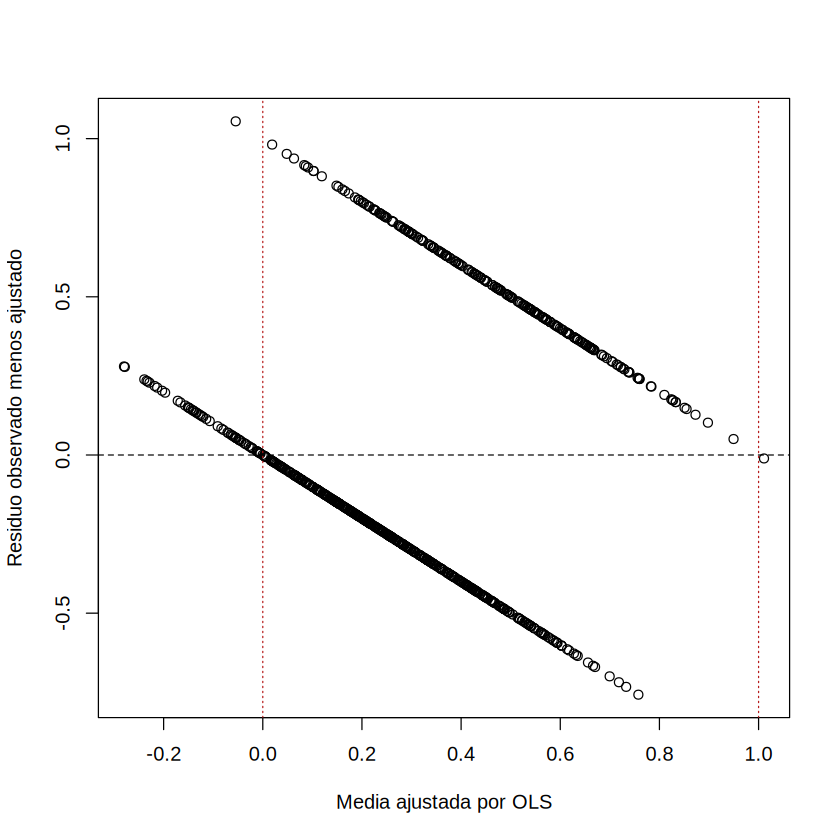

In [19]:
p1_ols <- lm(
        ever ~ x1,
        data = cohorte
    )
p1_ols_resumen <- data.frame(
        minimo = min( fitted( p1_ols ) ),
        maximo = max( fitted( p1_ols ) ),
        fuera_01 = sum(
                fitted( p1_ols ) < 0 |
                    fitted( p1_ols ) > 1
            )
    )
print( p1_ols_resumen )
plot(
        fitted( p1_ols ),
        residuals( p1_ols ),
        xlab = "Media ajustada por OLS",
        ylab = "Residuo observado menos ajustado"
    )
abline(
        h = 0,
        lty = 2
    )
abline(
        v = c( 0, 1 ),
        col = "#B71C1C",
        lty = 3
    )



Las líneas verticales están en 0 y en 1. En esta cohorte el OLS
deja `r p1_ols_resumen$fuera_01`
predicciones fuera de ese intervalo, y los residuos se ven en dos bandas.

| Fallo de OLS con `ever` | Componente del GLM que lo aborda | Motivo |
|:--|:--|:--|
| Media ajustada sin tope | Enlace logit | Pasa cualquier predictor real a una probabilidad entre 0 y 1. |
| Varianza que depende de la media | Familia Bernoulli | La varianza es `p(1-p)`, no una constante. |
| El cambio en probabilidad no es fijo | Predictor lineal y enlace | `x1`, `x2` y, si hace falta, su interacción actúan en log-odds; los puntos de probabilidad dependen del perfil. |

### Modelos e interacción

La escalera va del modelo nulo a solo fragilidad, luego al aditivo
y al final a la interacción. El LRT sirve cuando un modelo está
dentro del otro. AIC y BIC penalizan de otra forma. Elegimos con
los tres, con la pregunta que queremos contestar y mirando si el
ajuste converge.

La separación se comprueba antes de leer coeficientes. Si el
diagnóstico corta la ejecución, hay que tratarla (una logística
penalizada, por ejemplo) y volver a validar. Los primeros IC
asumen que las pacientes son independientes. El peso de la clínica
se estudia en P5.



In [20]:
p1_separacion <- glm(
        ever ~ x1 * x2,
        data = cohorte,
        family = binomial( "logit" ),
        method = detectseparation::detect_separation
    )
print( p1_separacion )
if ( any( is.infinite( coef( p1_separacion ) ) ) ) {
    stop( "Hay separación: resolver antes de interpretar." )
    }

p1_aditivo <- glm(
        ever ~ x1 + x2,
        data = cohorte,
        family = binomial( "logit" )
    )
p1_nulo <- glm(
        ever ~ 1,
        data = cohorte,
        family = binomial( "logit" )
    )
p1_solo_fragilidad <- glm(
        ever ~ x1,
        data = cohorte,
        family = binomial( "logit" )
    )
p1_interaccion <- glm(
        ever ~ x1 * x2,
        data = cohorte,
        family = binomial( "logit" )
    )
stopifnot(
        p1_nulo$converged,
        p1_solo_fragilidad$converged,
        p1_aditivo$converged,
        p1_interaccion$converged
    )
print( tabla_modelos(
        nulo = p1_nulo,
        fragilidad = p1_solo_fragilidad,
        aditivo = p1_aditivo,
        interaccion = p1_interaccion
    ) )
print( anova(
        p1_nulo,
        p1_solo_fragilidad,
        p1_aditivo,
        p1_interaccion,
        test = "LRT"
    ) )
print( anova(
        p1_aditivo,
        p1_interaccion,
        test = "LRT"
    ) )
print( tabla_efectos( p1_interaccion ) )

p1_final <- p1_aditivo
print( tabla_efectos( p1_final, terminos = c( "x1", "x2" ) ) )

p1_separacion_subgrupo <- lapply(
        split( cohorte, cohorte$x2 ),
        function( datos ) {
            prueba <- glm(
                    ever ~ x1,
                    data = datos,
                    family = binomial(),
                    method = detectseparation::detect_separation
                )
            data.frame(
                    pacientes = nrow( datos ),
                    eventos = sum( datos$ever ),
                    separacion = any( is.infinite( coef( prueba ) ) )
                )
            }
    )
print( dplyr::bind_rows(
        p1_separacion_subgrupo,
        .id = "x2"
    ) )


Implementation: ROI | Solver: lpsolve 
Separation: FALSE 
Existence of maximum likelihood estimates
(Intercept)          x1          x2       x1:x2 
          0           0           0           0 
0: finite value, Inf: infinity, -Inf: -infinity
       modelo      AIC      BIC    logLik   n
1        nulo 993.1655 997.8538 -495.5827 803
2  fragilidad 782.2320 791.6087 -389.1160 803
3     aditivo 776.4479 790.5130 -385.2240 803
4 interaccion 777.9182 796.6716 -384.9591 803
Analysis of Deviance Table

Model 1: ever ~ 1
Model 2: ever ~ x1
Model 3: ever ~ x1 + x2
Model 4: ever ~ x1 * x2
  Resid. Df Resid. Dev Df Deviance  Pr(>Chi)    
1       802     991.17                          
2       801     778.23  1  212.934 < 2.2e-16 ***
3       800     770.45  1    7.784  0.005271 ** 
4       799     769.92  1    0.530  0.466738    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
Analysis of Deviance Table

Model 1: ever ~ x1 + x2
Model 2: ever ~ x1 * x2
  Resid. Df Resid. Dev 


En el equipo 07 la interacción no indica que el tratamiento cambie
con la fragilidad, y **AIC y BIC coinciden** en el aditivo.
Dejamos `p1_final = p1_aditivo` para los efectos, las predicciones
y la evaluación. La interacción se queda como sensibilidad: que no
sea significativa no quiere decir que el tratamiento proteja igual
a todo el mundo.

### Efectos relativos, probabilidades y cambios absolutos

En el aditivo, `exp(beta_x1)` y `exp(beta_x2)` son OR constantes
en la escala de odds. Un OR no dice cuántos puntos de probabilidad
cambia el riesgo. Por eso calculamos la probabilidad en tres valores
observados de fragilidad, con y sin tratamiento: el cambio absoluto
sí depende de en qué punto de la curva esté la mujer.

Los intervalos salen de simular los coeficientes con su normal
multivariante. Son intervalos del modelo, no de la fractura de una
mujer concreta. El AME promedia sobre los perfiles que vemos: en
`x1`, la derivada de la probabilidad por una unidad de fragilidad;
en `x2`, tratada frente a no tratada. Lo damos en puntos
porcentuales. Es una asociación ajustada.



In [21]:
p1_fragilidad <- unname( quantile(
        cohorte$x1,
        probs = c( 0.25, 0.50, 0.75 )
    ) )
p1_perfiles <- expand.grid(
        x1 = p1_fragilidad,
        x2 = 0:1
    )
p1_X <- model.matrix(
        ~ x1 + x2,
        data = p1_perfiles
    )
set.seed( 20260926 )
p1_beta <- MASS::mvrnorm(
        n = 2000,
        mu = coef( p1_final ),
        Sigma = vcov( p1_final )
    )
p1_prob_sim <- plogis( p1_X %*% t( p1_beta ) )
p1_perfiles$probabilidad <- plogis(
        drop( p1_X %*% coef( p1_final ) )
    )
p1_perfiles$inferior <- apply(
        p1_prob_sim, 1, quantile, probs = 0.025
    )
p1_perfiles$superior <- apply(
        p1_prob_sim, 1, quantile, probs = 0.975
    )
print( p1_perfiles )


           x1 x2 probabilidad   inferior  superior
1 -0.71356015  0   0.14044325 0.10481963 0.1807950
2 -0.09956065  0   0.27864251 0.23143186 0.3289283
3  0.63322266  0   0.51890518 0.45876003 0.5780427
4 -0.71356015  1   0.09020665 0.06512455 0.1231684
5 -0.09956065  1   0.18989290 0.14982040 0.2359797
6  0.63322266  1   0.39559722 0.33198562 0.4644625


In [22]:
p1_sin <- which( p1_perfiles$x2 == 0 )
p1_con <- which( p1_perfiles$x2 == 1 )
p1_diferencia_sim <- 100 * (
        p1_prob_sim[ p1_con, ] - p1_prob_sim[ p1_sin, ]
    )
p1_L <- p1_X[ p1_con, ] - p1_X[ p1_sin, ]
p1_or_sim <- exp( p1_L %*% t( p1_beta ) )
p1_contrastes <- data.frame(
        x1 = p1_fragilidad,
        OR = exp( drop( p1_L %*% coef( p1_final ) ) ),
        OR_inf = apply( p1_or_sim, 1, quantile, 0.025 ),
        OR_sup = apply( p1_or_sim, 1, quantile, 0.975 ),
        cambio_pp = 100 * (
                p1_perfiles$probabilidad[ p1_con ] -
                    p1_perfiles$probabilidad[ p1_sin ]
            ),
        cambio_inf = apply(
                p1_diferencia_sim, 1, quantile, 0.025
            ),
        cambio_sup = apply(
                p1_diferencia_sim, 1, quantile, 0.975
            )
    )
print( p1_contrastes )


           x1        OR    OR_inf    OR_sup  cambio_pp cambio_inf cambio_sup
4 -0.71356015 0.6068334 0.4236546 0.8560788  -5.023660  -8.690232  -1.600246
5 -0.09956065 0.6068334 0.4236546 0.8560788  -8.874961 -15.047912  -2.866187
6  0.63322266 0.6068334 0.4236546 0.8560788 -12.330796 -21.028974  -3.880226


In [23]:
p1_X0 <- model.matrix(
        ~ x1 + x2,
        data = transform( cohorte, x2 = 0L )
    )
p1_X1 <- model.matrix(
        ~ x1 + x2,
        data = transform( cohorte, x2 = 1L )
    )
p1_ame_x2_sim <- 100 * colMeans(
        plogis( p1_X1 %*% t( p1_beta ) ) -
            plogis( p1_X0 %*% t( p1_beta ) )
    )
p1_X_observado <- model.matrix(
        ~ x1 + x2,
        data = cohorte
    )
p1_prob_observada_sim <- plogis(
        p1_X_observado %*% t( p1_beta )
    )
p1_ame_x1_sim <- 100 * colMeans(
        p1_prob_observada_sim *
            (1 - p1_prob_observada_sim)
    ) * p1_beta[ , "x1" ]

p1_ame <- data.frame(
        predictor = c( "x1: una unidad", "x2: 0 a 1" ),
        AME_pp = c(
                unname( 100 * mean(
                        fitted( p1_final ) *
                            (1 - fitted( p1_final ))
                    ) * coef( p1_final )[ "x1" ] ),
                100 * mean(
                        plogis( p1_X1 %*% coef( p1_final ) ) -
                            plogis( p1_X0 %*% coef( p1_final ) )
                    )
            ),
        inferior = c(
                unname( quantile( p1_ame_x1_sim, 0.025 ) ),
                unname( quantile( p1_ame_x2_sim, 0.025 ) )
            ),
        superior = c(
                unname( quantile( p1_ame_x1_sim, 0.975 ) ),
                unname( quantile( p1_ame_x2_sim, 0.975 ) )
            )
    )
print( p1_ame )
p1_nueva <- data.frame( x1 = 0, x2 = 1L )
p1_pred_nueva <- predict(
        p1_final,
        newdata = p1_nueva,
        type = "link",
        se.fit = TRUE
    )
print( transform(
        p1_nueva,
        probabilidad = plogis( p1_pred_nueva$fit ),
        inferior = plogis(
                p1_pred_nueva$fit - 1.96 * p1_pred_nueva$se.fit
            ),
        superior = plogis(
                p1_pred_nueva$fit + 1.96 * p1_pred_nueva$se.fit
            )
    ) )


       predictor    AME_pp  inferior superior
1 x1: una unidad 22.047058  19.71028 24.14463
2      x2: 0 a 1 -7.867793 -13.12022 -2.51907
  x1 x2 probabilidad  inferior  superior
1  0  1    0.2122878 0.1694399 0.2625458



### Predicción fuera de muestra: cinco grupos de clínicas

Cada clínica entra entera en un pliegue. Ajustamos el aditivo en
cuatro y predecimos el quinto, hasta tener una predicción por mujer
que no haya entrado en ese ajuste. Así vemos si el modelo viaja a
clínicas nuevas. La fórmula se eligió con toda la cohorte, de modo
que estas métricas **describen esa elección**: no validan, anidadas,
el proceso de selección.

AUC y Brier se comparan con un nulo que solo aprende la frecuencia
de fractura del entrenamiento. El umbral de la matriz se fijó en
**0,5 antes de ver** los resultados: cuenta aciertos y fallos, no
es una regla de cita. En calibración, lo deseable es intercepto 0
y pendiente 1. No ponemos IC que ignoren las clínicas o que los
mismos entrenamientos se reutilicen. Si después de esto cambiamos
la fórmula, hay que evaluar de nuevo.



In [24]:
set.seed( 26092026 )
p1_centros <- levels( cohorte$centro )
p1_mapa <- setNames(
        sample( rep( 1:5, length.out = length( p1_centros ) ) ),
        p1_centros
    )
p1_pliegue <- unname( p1_mapa[ as.character( cohorte$centro ) ] )
p1_oof <- p1_nulo_oof <- rep( NA_real_, nrow( cohorte ) )
p1_flexible_oof <- rep( NA_real_, nrow( cohorte ) )

for ( k in 1:5 ) {
    entrenamiento <- cohorte[ p1_pliegue != k, ]
    prueba <- p1_pliegue == k
    separacion <- glm(
            ever ~ x1 + x2,
            data = entrenamiento,
            family = binomial(),
            method = detectseparation::detect_separation
        )
    if ( any( is.infinite( coef( separacion ) ) ) ) {
        stop( "Separación en entrenamiento; revisar el procedimiento." )
        }
    ajuste <- glm(
            ever ~ x1 + x2,
            data = entrenamiento,
            family = binomial()
        )
    ajuste_flexible <- glm(
            ever ~ splines::ns( x1, df = 3 ) + x2,
            data = entrenamiento,
            family = binomial()
        )
    stopifnot( ajuste$converged, ajuste_flexible$converged )
    p1_oof[ prueba ] <- predict(
            ajuste,
            newdata = cohorte[ prueba, ],
            type = "response"
        )
    p1_nulo_oof[ prueba ] <- mean( entrenamiento$ever )
    p1_flexible_oof[ prueba ] <- predict(
            ajuste_flexible,
            newdata = cohorte[ prueba, ],
            type = "response"
        )
    }
stopifnot(
        all( is.finite( p1_oof ) ),
        all( is.finite( p1_flexible_oof ) )
    )


In [25]:
p1_roc <- pROC::roc(
        response = cohorte$ever,
        predictor = p1_oof,
        levels = c( 0, 1 ),
        direction = "<",
        quiet = TRUE
    )
print( data.frame(
        AUC = as.numeric( pROC::auc( p1_roc ) ),
        Brier = mean( (cohorte$ever - p1_oof)^2 ),
        Brier_nulo = mean( (cohorte$ever - p1_nulo_oof)^2 )
    ) )
print( data.frame(
        modelo = c( "Aditivo", "Spline exploratorio" ),
        AUC = c(
                as.numeric( pROC::auc( p1_roc ) ),
                as.numeric( pROC::auc(
                        cohorte$ever,
                        p1_flexible_oof,
                        direction = "<",
                        quiet = TRUE
                    ) )
            ),
        Brier = c(
                mean( (cohorte$ever - p1_oof)^2 ),
                mean( (cohorte$ever - p1_flexible_oof)^2 )
            )
    ) )
p1_validacion <- data.frame(
        y = cohorte$ever,
        p = p1_oof,
        eta = qlogis( pmin( pmax( p1_oof, 1e-6 ), 1 - 1e-6 ) )
    )
p1_calibracion <- glm(
        y ~ eta,
        data = p1_validacion,
        family = binomial()
    )
print( data.frame(
        intercepto = unname( coef( p1_calibracion )[ 1 ] ),
        pendiente = unname( coef( p1_calibracion )[ 2 ] )
    ) )
print( table(
        observado = factor( cohorte$ever, levels = 0:1 ),
        predicho = factor( as.integer( p1_oof >= 0.5 ), levels = 0:1 )
    ) )


        AUC     Brier Brier_nulo
1 0.7943451 0.1603051  0.2150858
               modelo       AUC     Brier
1             Aditivo 0.7943451 0.1603051
2 Spline exploratorio 0.7921679 0.1595786
   intercepto pendiente
1 -0.01897042 0.9683986
         predicho
observado   0   1
        0 499  57
        1 126 121


# A tibble: 8 × 4
  grupo     n predicho observado
  <int> <int>    <dbl>     <dbl>
1     1   101   0.0392    0.0495
2     2   101   0.0886    0.0693
3     3   101   0.139     0.198 
4     4   100   0.204     0.27  
5     5   100   0.292     0.24  
6     6   100   0.396     0.31  
7     7   100   0.544     0.54  
8     8   100   0.763     0.79  


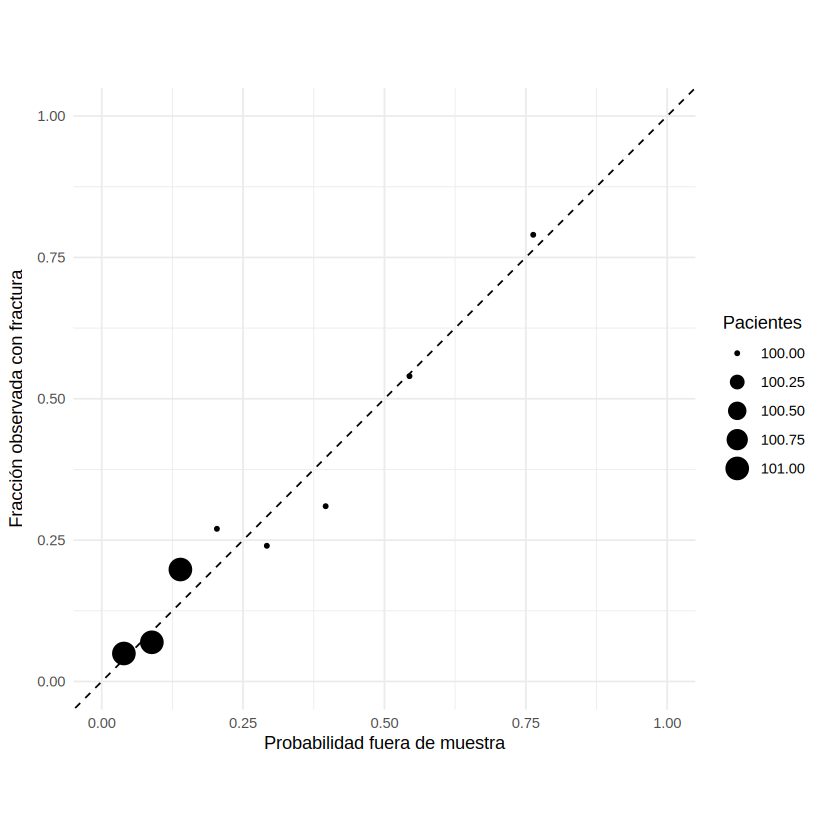

In [26]:
p1_cal_grupos <- p1_validacion |>
    dplyr::mutate( grupo = dplyr::ntile( p, 8 ) ) |>
    dplyr::group_by( grupo ) |>
    dplyr::summarise(
            n = dplyr::n(),
            predicho = mean( p ),
            observado = mean( y ),
            .groups = "drop"
        )
print( p1_cal_grupos )
ggplot2::ggplot(
        p1_cal_grupos,
        ggplot2::aes( predicho, observado )
    ) +
    ggplot2::geom_abline( intercept = 0, slope = 1, linetype = 2 ) +
    ggplot2::geom_point( ggplot2::aes( size = n ) ) +
    ggplot2::coord_equal( xlim = c( 0, 1 ), ylim = c( 0, 1 ) ) +
    ggplot2::labs(
            x = "Probabilidad fuera de muestra",
            y = "Fracción observada con fractura",
            size = "Pacientes"
        ) +
    ggplot2::theme_minimal()



Hosmer–Lemeshow acompaña al gráfico, pero el `p` se mueve al cambiar
el número de grupos y pierde fiabilidad si alguna celda esperada es
pequeña. Un `p` alto no demuestra que el modelo calibre bien. Lo
calculamos en el ajuste final y otra vez con seis grupos. Lo que
evalúa fuera de muestra sigue siendo el gráfico de arriba.



In [27]:
p1_hosmer_10 <- performance::performance_hosmer(
        p1_final,
        n_bins = 10
    )
p1_hosmer_6 <- performance::performance_hosmer(
        p1_final,
        n_bins = 6
    )
print( p1_hosmer_10 )
print( p1_hosmer_6 )


# Hosmer-Lemeshow Goodness-of-Fit Test

  Chi-squared: 11.515
           df:  8    
      p-value:  0.174



Summary: model seems to fit well.



# Hosmer-Lemeshow Goodness-of-Fit Test

  Chi-squared: 8.372
           df: 4    
      p-value: 0.079



Summary: model seems to fit well.




### Diagnóstico y decisión

Miramos residuos simulados y, aparte, un spline natural en la
fragilidad. Esa comparación no cambia por sí sola el modelo que
ya habíamos dejado para evaluar. Con una Bernoulli por mujer, el
test de dispersión informa poco: que no salga significativo no
prueba independencia ni quita de en medio que las clínicas difieran.

Con una observación por mujer y sin réplicas, ni `deviance / df` ni
el chi-cuadrado de la deviance valen como bondad de ajuste. El
gráfico de calibración enseña dónde se separan observado y predicho
por grupos de riesgo. Las clínicas entran como grupo en P5.



Warning message in newton(lsp = lsp, X = G$X, y = G$y, Eb = G$Eb, UrS = G$UrS, L = G$L, :
“Fitting terminated with step failure - check results carefully”


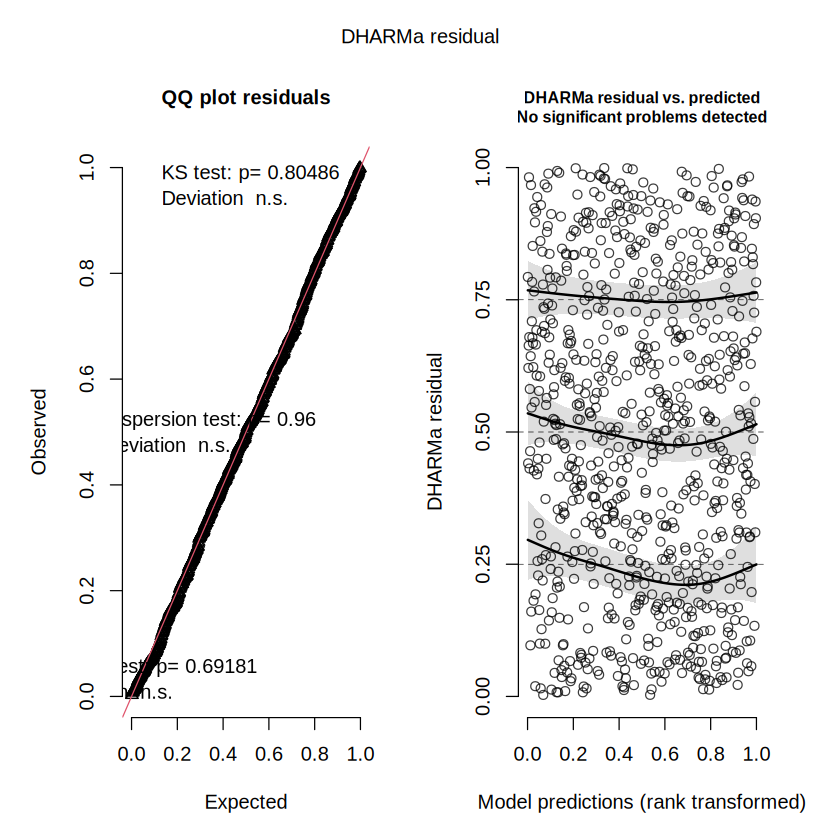


	DHARMa nonparametric dispersion test via sd of residuals fitted vs. simulated

data:  simulationOutput
dispersion = 1.0042, p-value = 0.96
alternative hypothesis: two.sided

    modelo      AIC     BIC    logLik   n
1   lineal 776.4479 790.513 -385.2240 803
2 flexible 774.4002 797.842 -382.2001 803
Analysis of Deviance Table

Model 1: ever ~ x1 + x2
Model 2: ever ~ splines::ns(x1, df = 3) + x2
  Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
1       800     770.45                       
2       798     764.40  2   6.0477  0.04861 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


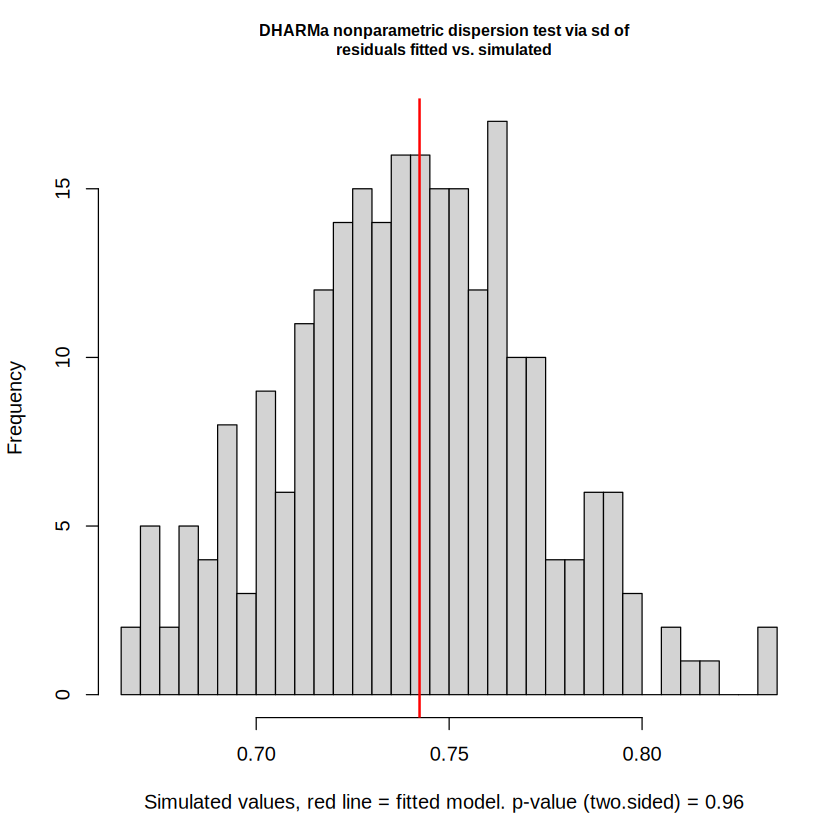

In [28]:
p1_residuos <- DHARMa::simulateResiduals(
        fittedModel = p1_final,
        n = 250,
        seed = 2609
    )
plot( p1_residuos )
print( DHARMa::testDispersion( p1_residuos ) )
p1_flexible <- glm(
        ever ~ splines::ns( x1, df = 3 ) + x2,
        data = cohorte,
        family = binomial()
    )
print( tabla_modelos(
        lineal = p1_final,
        flexible = p1_flexible
    ) )
print( anova(
        p1_final,
        p1_flexible,
        test = "LRT"
    ) )



### Binomial agrupada, como comprobación

`x1` es continua. Si agrupáramos cada valor exacto, casi todas las
celdas tendrían una sola mujer y el χ² no serviría. Cortamos la
fragilidad en **terciles** y los cruzamos con el tratamiento. Es
otra binomial, con `x1` en tres niveles: sus estadísticos no se
atribuyen a `p1_final`. Antes del χ² miramos cuántos éxitos y
fracasos espera el modelo en cada celda.



In [29]:
cortes_fragilidad <- unname( quantile(
        cohorte$x1,
        probs = seq( 0, 1, length.out = 4 )
    ) )
cohorte_agrupada <- cohorte |>
    mutate(
            tercil_x1 = cut(
                    x1,
                    breaks = cortes_fragilidad,
                    include.lowest = TRUE,
                    labels = c( "bajo", "medio", "alto" )
                )
        ) |>
    group_by( tercil_x1, x2 ) |>
    summarise(
            eventos = sum( ever ),
            pacientes = n(),
            sin_evento = pacientes - eventos,
            .groups = "drop"
        )

p1_binomial_agrupada <- glm(
        cbind( eventos, sin_evento ) ~ tercil_x1 + x2,
        data = cohorte_agrupada,
        family = binomial( "logit" )
    )

cohorte_agrupada$esperados_evento <-
    cohorte_agrupada$pacientes * fitted( p1_binomial_agrupada )
cohorte_agrupada$esperados_sin_evento <-
    cohorte_agrupada$pacientes - cohorte_agrupada$esperados_evento
print( cohorte_agrupada )

p1_pearson <- sum(
        residuals(
                p1_binomial_agrupada,
                type = "pearson"
            )^2
    )
p1_grados <- df.residual( p1_binomial_agrupada )
p1_bondad <- data.frame(
        estadistico = c( "Deviance", "Pearson" ),
        valor = c(
                deviance( p1_binomial_agrupada ),
                p1_pearson
            ),
        gl = p1_grados,
        p = pchisq(
                c(
                        deviance( p1_binomial_agrupada ),
                        p1_pearson
                    ),
                df = p1_grados,
                lower.tail = FALSE
            )
    )
print( p1_bondad )
print( data.frame(
        minimo_esperado = min(
                cohorte_agrupada$esperados_evento,
                cohorte_agrupada$esperados_sin_evento
            ),
        dispersion_pearson = p1_pearson / p1_grados
    ) )


# A tibble: 6 × 7
  tercil_x1    x2 eventos pacientes sin_evento esperados_evento esperados_sin_evento
  <fct>     <int>   <int>     <int>      <int>            <dbl>                <dbl>
1 bajo          0      14       139        125            13.4                 126. 
2 bajo          1       7       129        122             7.59                121. 
3 medio         0      44       150        106            49.1                 101. 
4 medio         1      31       117         86            25.9                  91.1
5 alto          0      96       147         51            91.5                  55.5
6 alto          1      55       121         66            59.5                  61.5
  estadistico    valor gl         p
1    Deviance 3.337523  2 0.1884804
2     Pearson 3.367427  2 0.1856831
  minimo_esperado dispersion_pearson
1        7.592784           1.683714



Quedan dos grados de libertad: seis celdas y cuatro parámetros.
En este banco los esperados pasan de cinco, pero con tan poca
resolución el `p` no avala el modelo continuo ni dice que las
clínicas sean homogéneas. Pearson/gl mide la dispersión **de esta
tabla**, no la de `p1_final`.

### Lectura de P1

A más fragilidad, más probabilidad de haber visto una fractura.
El OR por una unidad de `x1` es
`r round(exp(coef(p1_final)["x1"]), 2)`;
el del tratamiento,
`r round(exp(coef(p1_final)["x2"]), 2)`.
La interacción no aclara que esa asociación cambie con la fragilidad
(LRT `p =`
`r signif(anova(p1_aditivo, p1_interaccion, test="LRT")[["Pr(>Chi)"]][2], 3)`),
y el aditivo tiene menor AIC y menor BIC. En promedio, una unidad
más de fragilidad suma
`r round(p1_ame$AME_pp[1], 1)` puntos de probabilidad observada, y
el contraste del tratamiento es de
`r round(p1_ame$AME_pp[2], 1)` puntos. Los IC están en la tabla.
Para explicarlo, los cambios por perfil se entienden mejor que el OR
solo. Sigue siendo una asociación.

Para `x1 = 0` y `x2 = 1` el aditivo da
`r round(100*plogis(p1_pred_nueva$fit), 1)` % de fractura **durante
el seguimiento que esa mujer llegó a tener**, con IC aproximado de
`r round(100*plogis(p1_pred_nueva$fit-1.96*p1_pred_nueva$se.fit), 1)` % a
`r round(100*plogis(p1_pred_nueva$fit+1.96*p1_pred_nueva$se.fit), 1)` %.
Si hace falta un horizonte común, está en P2.

Fuera de la clínica de entrenamiento, el AUC es
`r round(as.numeric(pROC::auc(p1_roc)), 3)` y el Brier
`r round(mean((cohorte$ever-p1_oof)^2), 3)`,
frente a
`r round(mean((cohorte$ever-p1_nulo_oof)^2), 3)` del nulo.
Con el umbral 0,5 se dejan fuera
`r sum(cohorte$ever==1 & p1_oof<0.5)` de las
`r sum(cohorte$ever==1)` fracturas observadas. Hosmer–Lemeshow da
`p =` `r signif(p1_hosmer_10$p.value, 3)` con diez grupos y
`p =` `r signif(p1_hosmer_6$p.value, 3)` con seis: no vemos una
descalibración clara, pero el contraste se mueve al cambiar los
grupos. Tampoco hay separación en ningún brazo de tratamiento.
El spline de `x1`, sobre toda la cohorte, sugiere algo de curvatura.
Al repetirlo por clínicas, el Brier apenas cambia y el AUC baja un
poco. Nos quedamos con el aditivo porque se lee mejor; no porque
la recta en log-odds esté demostrada. Si al final se usara el
spline, habría que evaluarlo aparte. P5 es donde la inferencia
tiene en cuenta la clínica. Con el umbral 0,5 no se decide a quién
citar: lo que sí ordena el riesgo es la fragilidad, y los plazos
están en P2.

## P2. ¿Cuándo ocurre la fractura?

En `pp` hay una fila por mujer y revisión mientras estuvo en riesgo.
`y` vale 1 solo en la revisión de la fractura. El resto sale cuando
se le acaba la ventana.

El `ever` de P1 mezcla seguimientos cortos y largos. Para hablar de
plazos usamos el hazard de cada revisión, `h_t`, y
`S_t = producto(1 - h_k)`. Con enlace **cloglog**, `exp(beta)` es
una razón de hazards si el efecto no cambia con el tiempo. Ajustamos
también un logit: su exponencial es un OR por revisión, y solo sirve
para ver si la elección de enlace mueve el ajuste.

### Conjunto en riesgo y censura

Cada tasa divide los eventos entre las mujeres que **sí llegaron**
a esa revisión. El intervalo de Wilson es una incertidumbre binomial
simple: aquí no tiene en cuenta que las pacientes de una misma clínica
se parecen. El denominador baja por dos motivos distintos, fracturas
ya ocurridas y fin de la ventana, y no rellenamos revisiones que no
existieron. Quien se censura en `t` aporta `y = 0` hasta `t` y luego
desaparece. Si la censura es administrativa y no informativa, eso
dice que no se fracturó mientras la observamos. No dice que siguiera
sin fractura hasta la sexta revisión. Ese supuesto viene del diseño;
con las observadas no se puede comprobar.



# A tibble: 6 × 6
  periodo en_riesgo eventos hazard_observado inferior superior
  <fct>       <int>   <int>            <dbl>    <dbl>    <dbl>
1 1             803      59           0.0735   0.0574   0.0936
2 2             744      61           0.0820   0.0644   0.104 
3 3             683      50           0.0732   0.0560   0.0952
4 4             491      40           0.0815   0.0604   0.109 
5 5             300      19           0.0633   0.0409   0.0968
6 6             127      18           0.142    0.0916   0.213 


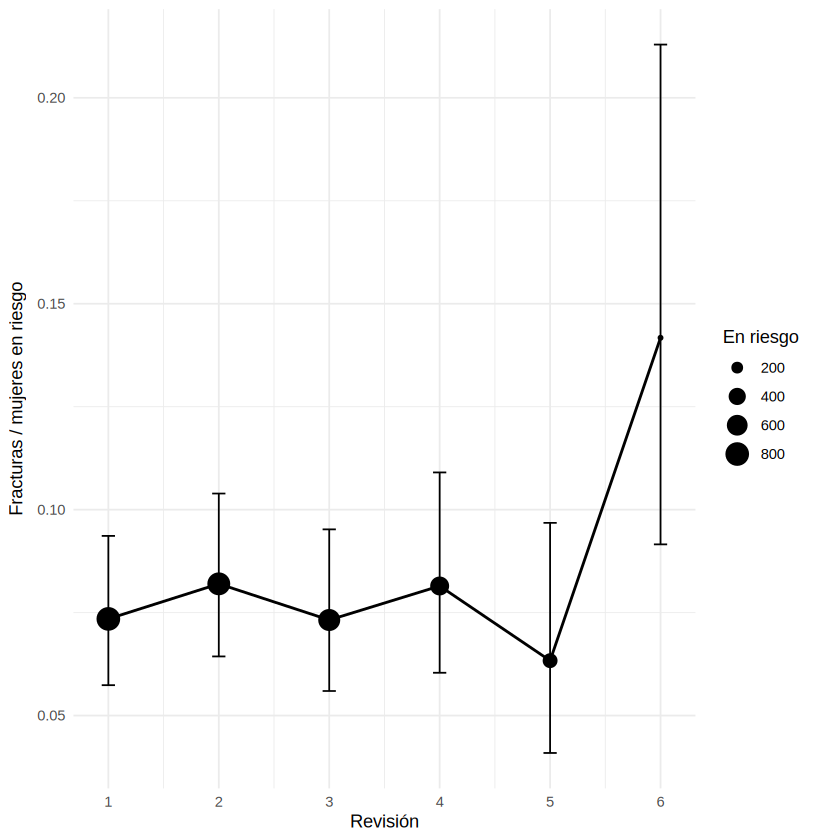

In [30]:
riesgo_periodo <- pp |>
    group_by( periodo ) |>
    summarise(
            en_riesgo = n(),
            eventos = sum( y ),
            hazard_observado = mean( y ),
            .groups = "drop"
        )

z_wilson <- qnorm( 0.975 )
denominador <- 1 + z_wilson^2 / riesgo_periodo$en_riesgo
centro_wilson <- (
        riesgo_periodo$hazard_observado +
            z_wilson^2 / (2 * riesgo_periodo$en_riesgo)
    ) / denominador
radio_wilson <- z_wilson * sqrt(
        riesgo_periodo$hazard_observado *
            (1 - riesgo_periodo$hazard_observado) /
            riesgo_periodo$en_riesgo +
            z_wilson^2 / (4 * riesgo_periodo$en_riesgo^2)
    ) / denominador

riesgo_periodo$inferior <- pmax( 0, centro_wilson - radio_wilson )
riesgo_periodo$superior <- pmin( 1, centro_wilson + radio_wilson )
print( riesgo_periodo )

ggplot(
        riesgo_periodo,
        aes( x = as.integer( periodo ), y = hazard_observado )
    ) +
    geom_errorbar(
            aes( ymin = inferior, ymax = superior ),
            width = 0.12
        ) +
    geom_line( linewidth = 0.8 ) +
    geom_point( aes( size = en_riesgo ) ) +
    scale_x_continuous( breaks = 1:6 ) +
    labs(
            x = "Revisión",
            y = "Fracturas / mujeres en riesgo",
            size = "En riesgo"
        ) +
    theme_minimal()



### Descripción de supervivencia sin covariables

Kaplan–Meier dibuja cómo cae la supervivencia observada y cuenta
la censura. La separación entre curvas de tratamiento no está
ajustada por fragilidad ni por clínica: de momento es una
descripción, no el efecto del tratamiento.



Call: survfit(formula = survival::Surv(tiempo, evento) ~ x2, data = cohorte, 
    conf.type = "log-log")

                x2=0 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1    436      37    0.915  0.0133        0.885        0.938
    2    399      46    0.810  0.0188        0.770        0.843
    3    353      29    0.743  0.0209        0.699        0.782
    4    251      20    0.684  0.0231        0.636        0.727
    5    160      12    0.633  0.0257        0.580        0.680
    6     71      10    0.544  0.0342        0.474        0.608

                x2=1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1    367      22    0.940  0.0124        0.910        0.960
    2    345      15    0.899  0.0157        0.864        0.926
    3    330      21    0.842  0.0190        0.800        0.876
    4    240      20    0.772  0.0230        0.723        0.813
    5    140       7    0.733  0.0261        0.678        0.780
    6     56     

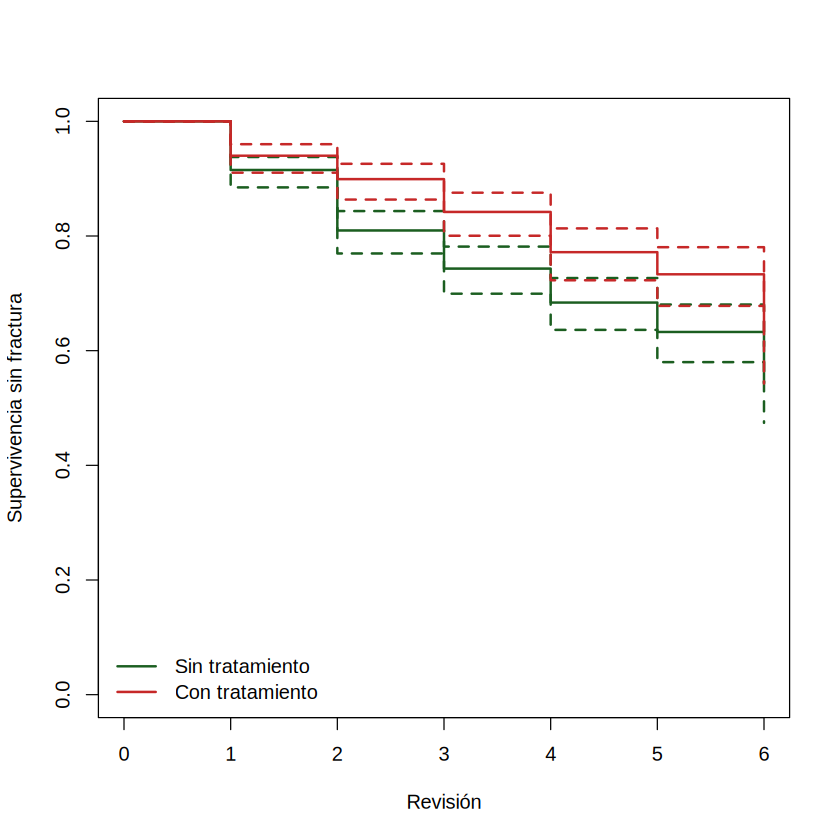

In [31]:
km_tratamiento <- survival::survfit(
        survival::Surv( tiempo, evento ) ~ x2,
        data = cohorte,
        conf.type = "log-log"
    )
print( summary( km_tratamiento, times = 1:6, extend = TRUE ) )
plot(
        km_tratamiento,
        conf.int = TRUE,
        col = c( "#1B5E20", "#C62828" ),
        lwd = 2,
        xlab = "Revisión",
        ylab = "Supervivencia sin fractura"
    )
legend(
        "bottomleft",
        legend = c( "Sin tratamiento", "Con tratamiento" ),
        col = c( "#1B5E20", "#C62828" ),
        lwd = 2,
        bty = "n"
    )

p2_logrank <- survival::survdiff(
        survival::Surv( tiempo, evento ) ~ x2,
        data = cohorte
    )
print( p2_logrank )
print( data.frame(
        estadistico = unname( p2_logrank$chisq ),
        gl = length( p2_logrank$n ) - 1,
        p = pchisq(
                p2_logrank$chisq,
                df = length( p2_logrank$n ) - 1,
                lower.tail = FALSE
            )
    ) )



El log-rank compara esas curvas sin `x1` y sin clínica. El efecto
ajustado del tratamiento sale del cloglog de la sección siguiente.

### GLM y GLMM de riesgo en tiempo discreto

`periodo` entra como factor para que el riesgo base pueda cambiar
en cada revisión, y la clínica como intercepto aleatorio. Comparamos
el modelo sin clínica y con clínica, y el cloglog con el logit, siempre
sobre las mismas filas. AIC y BIC dicen si el ajuste compensa la
complejidad; no ponen dos enlaces en la misma escala. Añadir una
varianza aleatoria no se contrasta con el chi-cuadrado de siempre:
la varianza cero está en el borde del espacio de parámetros.



In [32]:
p2_control <- lme4::glmerControl(
        optimizer = "bobyqa",
        optCtrl = list( maxfun = 200000 )
    )
p2_pooled <- glm(
        y ~ periodo + x1 + x2,
        data = pp,
        family = binomial( "cloglog" )
    )
p2_clinica <- lme4::glmer(
        y ~ periodo + x1 + x2 + ( 1 | centro ),
        data = pp,
        family = binomial( "cloglog" ),
        control = p2_control
    )
p2_logit <- lme4::glmer(
        y ~ periodo + x1 + x2 + ( 1 | centro ),
        data = pp,
        family = binomial( "logit" ),
        control = p2_control
    )

print( tabla_modelos(
        cloglog_pooled = p2_pooled,
        cloglog_clinica = p2_clinica,
        logit_clinica = p2_logit
    ) )
print( lme4::VarCorr( p2_clinica ) )
print( data.frame(
        modelo = c( "cloglog clínica", "logit clínica" ),
        singular = c(
                lme4::isSingular( p2_clinica ),
                lme4::isSingular( p2_logit )
            ),
        convergencia = c(
                length( p2_clinica@optinfo$conv$lme4$messages ) == 0,
                length( p2_logit@optinfo$conv$lme4$messages ) == 0
            )
    ) )


           modelo      AIC      BIC    logLik    n
1  cloglog_pooled 1483.213 1531.649 -733.6063 3148
2 cloglog_clinica 1457.243 1511.734 -719.6214 3148
3   logit_clinica 1457.419 1511.910 -719.7094 3148
 Groups Name        Std.Dev.
 centro (Intercept) 0.51847 
           modelo singular convergencia
1 cloglog clínica    FALSE         TRUE
2   logit clínica    FALSE         TRUE


In [33]:
efectos_pooled <- tabla_efectos(
        p2_pooled,
        terminos = c( "x1", "x2" )
    )
efectos_clinica <- tabla_efectos(
        p2_clinica,
        terminos = c( "x1", "x2" )
    )
efectos_logit <- tabla_efectos(
        p2_logit,
        terminos = c( "x1", "x2" )
    )

efectos_pooled$escala <- "HR subyacente, pooled"
efectos_clinica$escala <- "HR subyacente, condicional a clínica"
efectos_logit$escala <- "OR por revisión, condicional a clínica"

print( rbind(
        efectos_pooled,
        efectos_clinica,
        efectos_logit
    ) )


  termino       beta      error    efecto  inferior  superior            p
1      x1  1.1487236 0.07608653 3.1541644 2.7171859 3.6614179 1.679501e-51
2      x2 -0.4775953 0.13252424 0.6202732 0.4783857 0.8042440 3.135577e-04
3      x1  1.1724329 0.07838180 3.2298409 2.7698893 3.7661692 1.381696e-50
4      x2 -0.5309227 0.13434030 0.5880621 0.4519314 0.7651981 7.747704e-05
5      x1  1.2776156 0.09053805 3.5880742 3.0046597 4.2847703 3.232525e-45
6      x2 -0.5693718 0.14848404 0.5658808 0.4229949 0.7570330 1.257865e-04
                                  escala
1                  HR subyacente, pooled
2                  HR subyacente, pooled
3   HR subyacente, condicional a clínica
4   HR subyacente, condicional a clínica
5 OR por revisión, condicional a clínica
6 OR por revisión, condicional a clínica



La clínica también se ve en los coeficientes y en sus errores
estándar. La comparación usa los mismos periodos y las mismas
covariables. El GLM *pooled* trata como independientes a mujeres
de clínicas distintas y no deja sitio a una variación basal entre
centros. Con una sola varianza aleatoria, el LRT de frontera de
abajo mezcla, a partes iguales, una masa en cero y una chi-cuadrado
con un grado de libertad. Lo leemos junto al AIC y al tamaño de
esa varianza, no como un p-valor cerrado.



In [34]:
p2_terminos <- c( "x1", "x2" )
p2_compara_coef <- data.frame(
        termino = p2_terminos,
        beta_pooled = coef( p2_pooled )[ p2_terminos ],
        beta_clinica = lme4::fixef( p2_clinica )[ p2_terminos ],
        se_pooled = sqrt( diag( vcov( p2_pooled ) ) )[ p2_terminos ],
        se_clinica = sqrt( diag( vcov( p2_clinica ) ) )[ p2_terminos ]
    )
print( p2_compara_coef )

p2_lrt_centro <- 2 * (
        as.numeric( logLik( p2_clinica ) ) -
            as.numeric( logLik( p2_pooled ) )
    )
p2_p_frontera <- 0.5 * pchisq(
        p2_lrt_centro,
        df = 1,
        lower.tail = FALSE
    )
print( data.frame(
        lrt = p2_lrt_centro,
        p_frontera = p2_p_frontera
    ) )


   termino beta_pooled beta_clinica  se_pooled se_clinica
x1      x1   1.1487236    1.1724329 0.07608653  0.0783818
x2      x2  -0.4775953   -0.5309227 0.13252424  0.1343403
       lrt   p_frontera
1 27.96963 6.161712e-08



### ¿Permanece constante el efecto en las revisiones?

En el cloglog aditivo, el efecto de `x1` o de `x2` es el mismo en
todas las revisiones, en esa escala. Para verlo, dejamos que ambos
interaccionen con `periodo`. El LRT compara **efectos fijos** y
mantiene la misma parte aleatoria. Lo miramos con la convergencia,
el AIC, el BIC y los intervalos. En las revisiones tardías quedan
pocas mujeres, así que el contraste tiene poca potencia.



In [35]:
p2_variable <- lme4::glmer(
        y ~ periodo * ( x1 + x2 ) + ( 1 | centro ),
        data = pp,
        family = binomial( "cloglog" ),
        control = p2_control
    )

print( tabla_modelos(
        proporcional = p2_clinica,
        efecto_variable = p2_variable
    ) )
print( anova(
        p2_clinica,
        p2_variable,
        test = "Chisq"
    ) )
print( list(
        singular = lme4::isSingular( p2_variable ),
        mensajes = p2_variable@optinfo$conv$lme4$messages
    ) )


           modelo      AIC      BIC    logLik    n
1    proporcional 1457.243 1511.734 -719.6214 3148
2 efecto_variable 1469.157 1584.193 -715.5784 3148
Data: pp
Models:
p2_clinica: y ~ periodo + x1 + x2 + (1 | centro)
p2_variable: y ~ periodo * (x1 + x2) + (1 | centro)
            npar    AIC    BIC  logLik -2*log(L)  Chisq Df Pr(>Chisq)
p2_clinica     9 1457.2 1511.7 -719.62    1439.2                     
p2_variable   19 1469.2 1584.2 -715.58    1431.2 8.0861 10     0.6204
$singular
[1] FALSE

$mensajes
NULL




### Riesgo y supervivencia para perfiles definidos

Comparamos `x1 = 0` y `x1 = 1`, con y sin tratamiento. El efecto
aleatorio se fija en cero: es una clínica en el centro de la
distribución, en la escala del predictor, no la media de todas
las clínicas. El riesgo acumulado de cada revisión es `1 - S_t`
y ahí sí hay un horizonte común.

Los intervalos simulan la incertidumbre de los efectos fijos y
dejan quieta la varianza entre clínicas. No son intervalos de
predicción para una mujer nueva ni para una clínica nueva.



In [36]:
p2_perfiles <- expand.grid(
        periodo = factor(
                as.character( 1:6 ),
                levels = levels( pp$periodo )
            ),
        x1 = c( 0, 1 ),
        x2 = c( 0, 1 )
    )
p2_perfiles$centro <- factor(
        levels( pp$centro )[ 1 ],
        levels = levels( pp$centro )
    )

p2_perfiles$hazard <- predict(
        p2_clinica,
        newdata = p2_perfiles,
        type = "response",
        re.form = NA
    )
p2_perfiles <- p2_perfiles |>
    arrange( x1, x2, periodo ) |>
    group_by( x1, x2 ) |>
    mutate(
            supervivencia = cumprod( 1 - hazard ),
            riesgo_acumulado = 1 - supervivencia
        ) |>
    ungroup()

print( p2_perfiles[
        c( "periodo", "x1", "x2", "hazard",
           "supervivencia", "riesgo_acumulado" )
    ] )


# A tibble: 24 × 6
   periodo    x1    x2 hazard supervivencia riesgo_acumulado
   <fct>   <dbl> <dbl>  <dbl>         <dbl>            <dbl>
 1 1           0     0 0.0462         0.954           0.0462
 2 2           0     0 0.0628         0.894           0.106 
 3 3           0     0 0.0672         0.834           0.166 
 4 4           0     0 0.0874         0.761           0.239 
 5 5           0     0 0.0814         0.699           0.301 
 6 6           0     0 0.211          0.552           0.448 
 7 1           0     1 0.0274         0.973           0.0274
 8 2           0     1 0.0374         0.936           0.0638
 9 3           0     1 0.0401         0.899           0.101 
10 4           0     1 0.0523         0.852           0.148 
# ℹ 14 more rows


In [37]:
set.seed( 220926 )
p2_X <- model.matrix(
        ~ periodo + x1 + x2,
        data = p2_perfiles
    )
p2_beta_sim <- MASS::mvrnorm(
        n = 1500,
        mu = lme4::fixef( p2_clinica ),
        Sigma = as.matrix( vcov( p2_clinica ) )
    )
p2_eta_sim <- p2_X %*% t( p2_beta_sim )
p2_hazard_sim <- 1 - exp( -exp( p2_eta_sim ) )

p2_perfiles$hazard_inf <- apply(
        p2_hazard_sim,
        1,
        quantile,
        probs = 0.025
    )
p2_perfiles$hazard_sup <- apply(
        p2_hazard_sim,
        1,
        quantile,
        probs = 0.975
    )
p2_perfiles$riesgo_inf <- NA_real_
p2_perfiles$riesgo_sup <- NA_real_

for ( indice in split(
        seq_len( nrow( p2_perfiles ) ),
        interaction( p2_perfiles$x1, p2_perfiles$x2 )
    ) ) {
    supervivencia_sim <- apply(
            1 - p2_hazard_sim[ indice, , drop = FALSE ],
            2,
            cumprod
        )
    riesgo_sim <- 1 - supervivencia_sim
    p2_perfiles$riesgo_inf[ indice ] <- apply(
            riesgo_sim, 1, quantile, probs = 0.025
        )
    p2_perfiles$riesgo_sup[ indice ] <- apply(
            riesgo_sim, 1, quantile, probs = 0.975
        )
    }

print( p2_perfiles[ p2_perfiles$periodo %in% c( "3", "6" ),
                   c( "periodo", "x1", "x2", "riesgo_acumulado",
                      "riesgo_inf", "riesgo_sup" ) ] )


# A tibble: 8 × 6
  periodo    x1    x2 riesgo_acumulado riesgo_inf riesgo_sup
  <fct>   <dbl> <dbl>            <dbl>      <dbl>      <dbl>
1 3           0     0            0.166     0.127       0.221
2 6           0     0            0.448     0.358       0.564
3 3           0     1            0.101     0.0740      0.140
4 6           0     1            0.295     0.225       0.393
5 3           1     0            0.444     0.355       0.547
6 6           1     0            0.854     0.756       0.935
7 3           1     1            0.292     0.220       0.378
8 6           1     1            0.677     0.562       0.810



### Hazard basal y supervivencia hasta cada revisión

El hazard basal del cloglog mixto es el de `x1 = 0`, `x2 = 0` y
efecto de clínica en cero. `S_t` multiplica `1 - h_k` desde la
primera revisión hasta la `t`. Así se separa la probabilidad de
fracturarse **en** una revisión de la de llegar a ella sin
fractura. Los intervalos solo recogen incertidumbre de los efectos
fijos. En la última revisión hay muchas menos mujeres.



# A tibble: 6 × 8
  periodo en_riesgo hazard hazard_inf hazard_sup supervivencia supervivencia_inf
  <fct>       <int>  <dbl>      <dbl>      <dbl>         <dbl>             <dbl>
1 1             803 0.0462     0.0321     0.0671         0.954             0.933
2 2             744 0.0628     0.0445     0.0889         0.894             0.856
3 3             683 0.0672     0.0457     0.0975         0.834             0.779
4 4             491 0.0874     0.0591     0.129          0.761             0.692
5 5             300 0.0814     0.0513     0.133          0.699             0.613
6 6             127 0.211      0.135      0.323          0.552             0.436
# ℹ 1 more variable: supervivencia_sup <dbl>


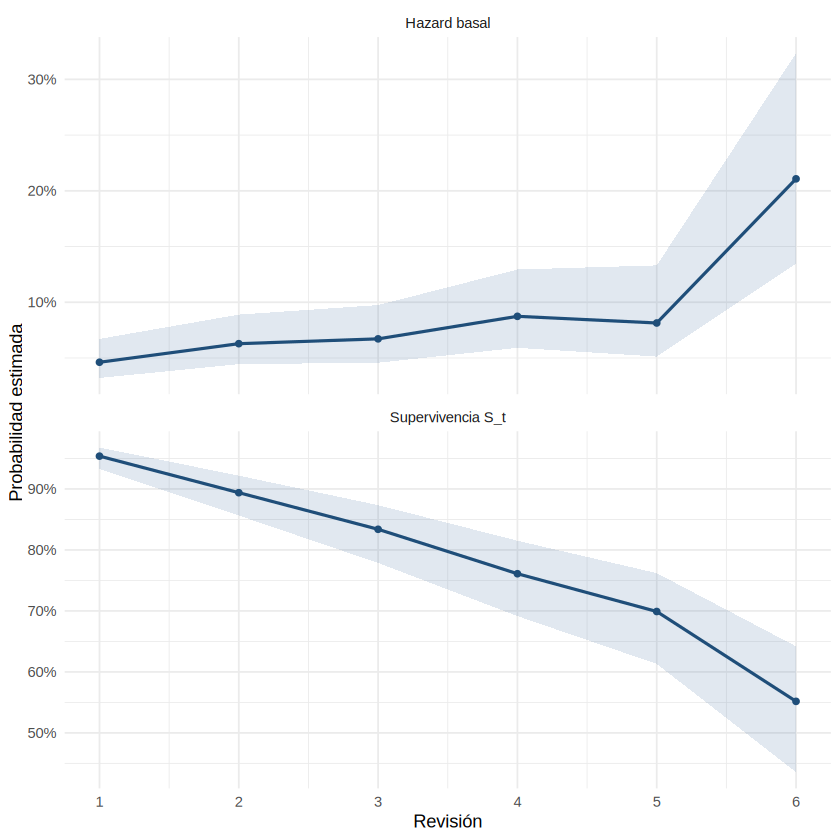

In [38]:
p2_base <- p2_perfiles |>
    filter( x1 == 0, x2 == 0 ) |>
    left_join(
            riesgo_periodo |>
                select( periodo, en_riesgo ),
            by = "periodo"
        ) |>
    mutate(
            supervivencia_inf = 1 - riesgo_sup,
            supervivencia_sup = 1 - riesgo_inf
        )

print( p2_base |>
    select(
            periodo,
            en_riesgo,
            hazard,
            hazard_inf,
            hazard_sup,
            supervivencia,
            supervivencia_inf,
            supervivencia_sup
        ) )

p2_base_largo <- bind_rows(
        data.frame(
                periodo = p2_base$periodo,
                medida = "Hazard basal",
                estimacion = p2_base$hazard,
                inferior = p2_base$hazard_inf,
                superior = p2_base$hazard_sup
            ),
        data.frame(
                periodo = p2_base$periodo,
                medida = "Supervivencia S_t",
                estimacion = p2_base$supervivencia,
                inferior = p2_base$supervivencia_inf,
                superior = p2_base$supervivencia_sup
            )
    )

ggplot(
        p2_base_largo,
        aes( x = as.integer( periodo ), y = estimacion )
    ) +
    geom_ribbon(
            aes( ymin = inferior, ymax = superior ),
            fill = "#4E79A7",
            alpha = 0.17
        ) +
    geom_line( color = "#1F4E79", linewidth = 0.9 ) +
    geom_point( color = "#1F4E79" ) +
    facet_wrap( ~ medida, ncol = 1, scales = "free_y" ) +
    scale_x_continuous( breaks = 1:6 ) +
    scale_y_continuous(
            labels = function( x ) paste0( round( 100 * x ), "%" )
        ) +
    labs(
            x = "Revisión",
            y = "Probabilidad estimada"
        ) +
    theme_minimal()



El hazard basal pasa de
`r round(100*p2_base$hazard[1], 1)` % en la primera revisión a
`r round(100*p2_base$hazard[6], 1)` % en la sexta. No pedimos que
suba en cada paso: entre medias hay una oscilación pequeña, y el
último punto se apoya en solo `r p2_base$en_riesgo[6]` mujeres.



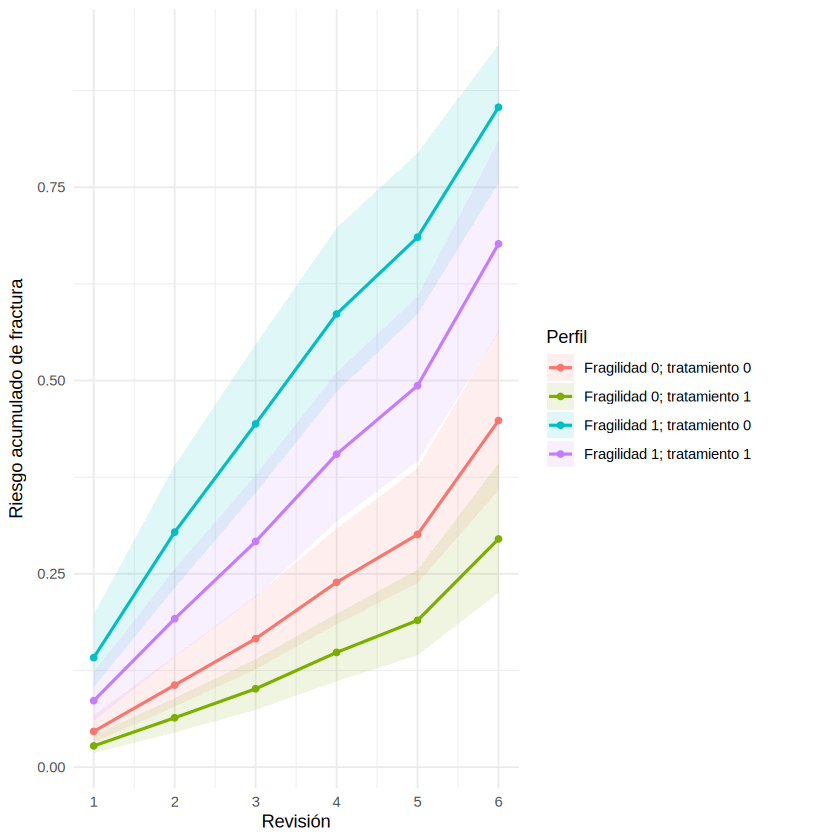

In [39]:
p2_perfiles$perfil <- factor(
        paste0(
                "Fragilidad ", p2_perfiles$x1,
                "; tratamiento ", p2_perfiles$x2
            )
    )

ggplot(
        p2_perfiles,
        aes(
                x = as.integer( periodo ),
                y = riesgo_acumulado,
                color = perfil,
                fill = perfil
            )
    ) +
    geom_ribbon(
            aes( ymin = riesgo_inf, ymax = riesgo_sup ),
            alpha = 0.12,
            color = NA
        ) +
    geom_line( linewidth = 0.9 ) +
    geom_point() +
    scale_x_continuous( breaks = 1:6 ) +
    labs(
            x = "Revisión",
            y = "Riesgo acumulado de fractura",
            color = "Perfil",
            fill = "Perfil"
        ) +
    theme_minimal()



### Comprobación del ajuste temporal

Primero miramos el ajuste en las mujeres que llegan a cada periodo
y los residuos simulados del GLMM. La tabla por periodo casi no
informa: al haber un intercepto por revisión, observado y predicho
coinciden casi por construcción. La calibración que sí dice algo
es la de **terciles de riesgo**, más abajo. Todo esto usa la misma
cohorte del ajuste. Si cambiáramos la fórmula, habría que rehacer
predicciones y lectura.



# A tibble: 6 × 4
  periodo en_riesgo observado predicho
  <fct>       <int>     <dbl>    <dbl>
1 1             803    0.0735   0.0728
2 2             744    0.0820   0.0818
3 3             683    0.0732   0.0735
4 4             491    0.0815   0.0816
5 5             300    0.0633   0.0634
6 6             127    0.142    0.139 


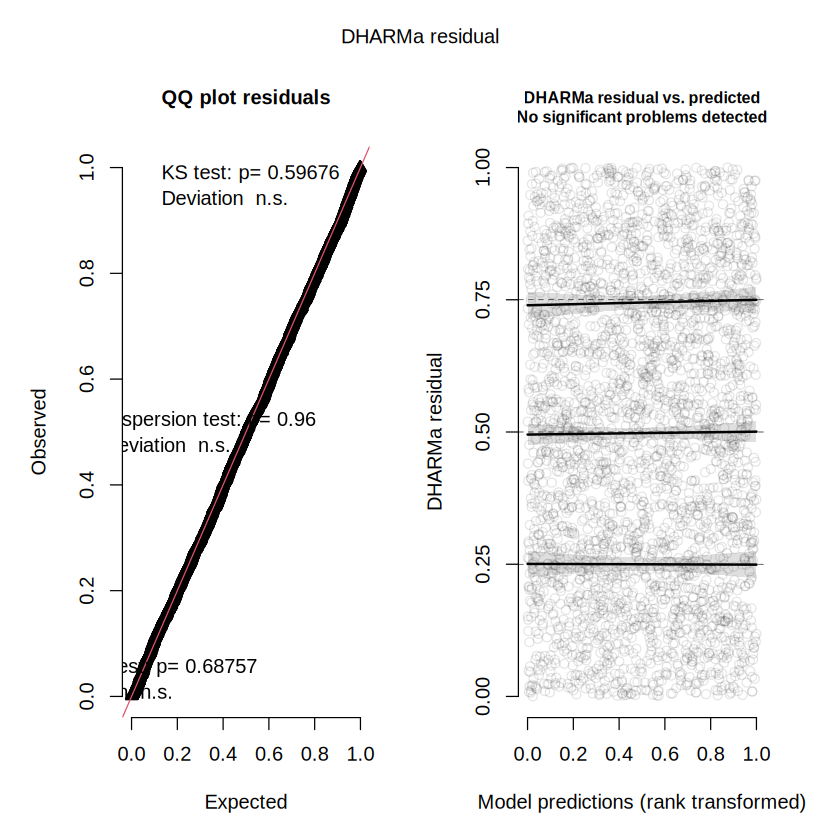


	DHARMa nonparametric dispersion test via sd of residuals fitted vs. simulated

data:  simulationOutput
dispersion = 1.0007, p-value = 0.96
alternative hypothesis: two.sided



DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details

DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details



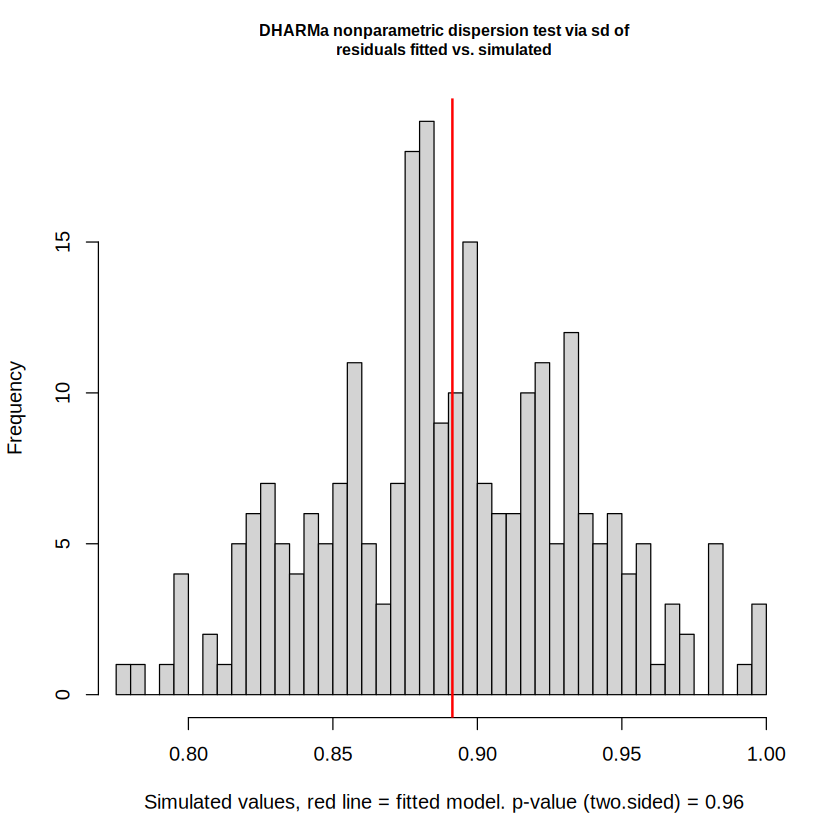

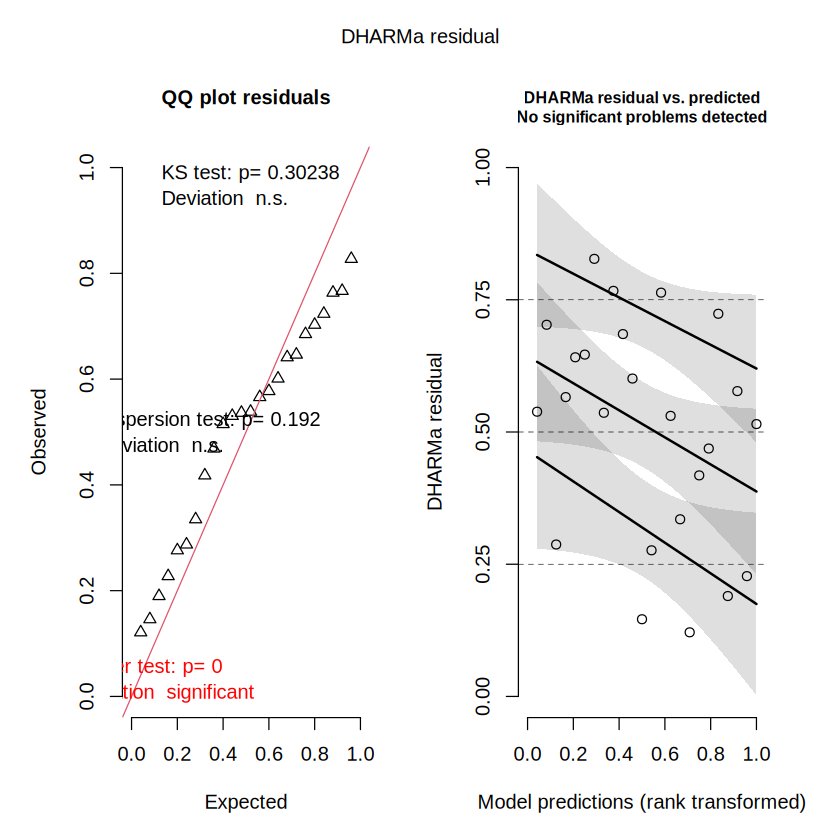

In [40]:
p2_pred_ajuste <- predict(
        p2_clinica,
        type = "response"
    )
p2_calibracion <- pp |>
    mutate( predicho = p2_pred_ajuste ) |>
    group_by( periodo ) |>
    summarise(
            en_riesgo = n(),
            observado = mean( y ),
            predicho = mean( predicho ),
            .groups = "drop"
        )
print( p2_calibracion )

p2_residuos <- DHARMa::simulateResiduals(
        fittedModel = p2_clinica,
        n = 250,
        seed = 2209
    )
plot( p2_residuos )
print( DHARMa::testDispersion( p2_residuos ) )

p2_por_centro <- DHARMa::recalculateResiduals(
        p2_residuos,
        group = pp$centro
    )
plot( p2_por_centro )



### Forma de `x1`: residuos de martingala

El residuo de martingala, en esta versión discreta, resta a la
fractura de cada mujer la suma de sus hazards ajustados, y solo
en las revisiones que de verdad tuvo. Si el suavizado frente a
`x1` aún sube o baja, la forma lineal se queda corta. También
probamos un término cuadrático, con el mismo efecto de clínica.
Es exploratorio: un p-valor no decide solo.



      modelo      AIC      BIC    logLik    n
1     lineal 1457.243 1511.734 -719.6214 3148
2 cuadratico 1459.092 1519.637 -719.5459 3148
Data: pp
Models:
p2_clinica: y ~ periodo + x1 + x2 + (1 | centro)
p2_cuadratico: y ~ periodo + x1 + I(x1^2) + x2 + (1 | centro)
              npar    AIC    BIC  logLik -2*log(L) Chisq Df Pr(>Chisq)
p2_clinica       9 1457.2 1511.7 -719.62    1439.2                    
p2_cuadratico   10 1459.1 1519.6 -719.55    1439.1 0.151  1     0.6975
NULL


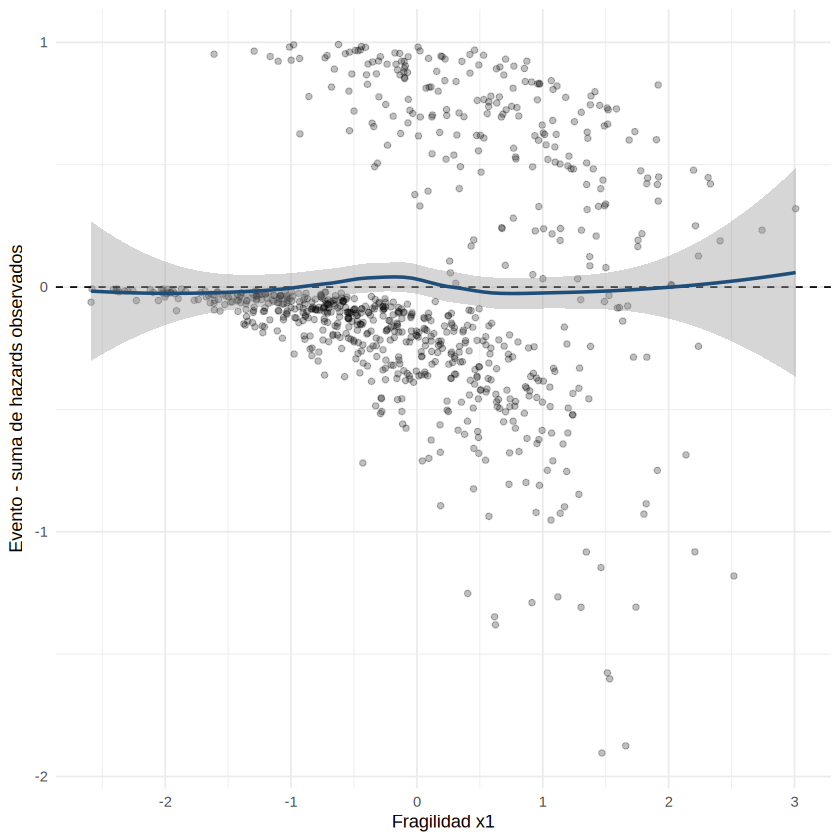

In [41]:
p2_martingala <- pp |>
    mutate( hazard_ajustado = as.numeric( p2_pred_ajuste ) ) |>
    group_by( id ) |>
    summarise(
            esperado = sum( hazard_ajustado ),
            .groups = "drop"
        ) |>
    left_join(
            cohorte |>
                select( id, x1, evento ),
            by = "id"
        ) |>
    mutate( residuo = evento - esperado )

ggplot(
        p2_martingala,
        aes( x = x1, y = residuo )
    ) +
    geom_hline( yintercept = 0, linetype = 2 ) +
    geom_point( alpha = 0.25 ) +
    geom_smooth(
            method = "loess",
            formula = y ~ x,
            se = TRUE,
            color = "#1F4E79"
        ) +
    labs(
            x = "Fragilidad x1",
            y = "Evento - suma de hazards observados"
        ) +
    theme_minimal()

p2_cuadratico <- lme4::glmer(
        y ~ periodo + x1 + I( x1^2 ) + x2 + ( 1 | centro ),
        data = pp,
        family = binomial( "cloglog" ),
        control = p2_control
    )
print( tabla_modelos(
        lineal = p2_clinica,
        cuadratico = p2_cuadratico
    ) )
print( anova(
        p2_clinica,
        p2_cuadratico,
        test = "Chisq"
    ) )
print( p2_cuadratico@optinfo$conv$lme4$messages )



### Calibración por terciles de riesgo

A cada mujer le proyectamos los seis periodos con sus covariables
de inicio. Kaplan–Meier es una supervivencia **marginal**, mezclando
clínicas, así que la del GLMM hay que integrarla sobre la
distribución del intercepto aleatorio. Esa fragilidad de clínica
es la misma en todos los periodos de una mujer: primero se calcula
su supervivencia para cada valor del intercepto y después se promedia
con cuadratura normal. Si se promediaran los hazards y luego se
multiplicaran, saldría otra curva.

Quien se censura antes de la sexta tiene una supervivencia
**predicha** hasta el final, no un desenlace inventado. Los
terciles se hacen con el riesgo marginal `1 - S_6`. Comparamos
la media de `S_t` con Kaplan–Meier, que dentro de cada grupo sí
trata la censura. Las bandas del gráfico son las de Kaplan–Meier.
La comparación es aparente: el modelo se ajustó con esta misma cohorte.



  tercil en_riesgo        km    km_inf    km_sup supervivencia_predicha
1   Bajo        62 0.8554197 0.7735737 0.9093831              0.8561952
2  Medio        45 0.6278679 0.5269389 0.7131126              0.6253874
3   Alto        20 0.2443844 0.1606823 0.3376093              0.2473406


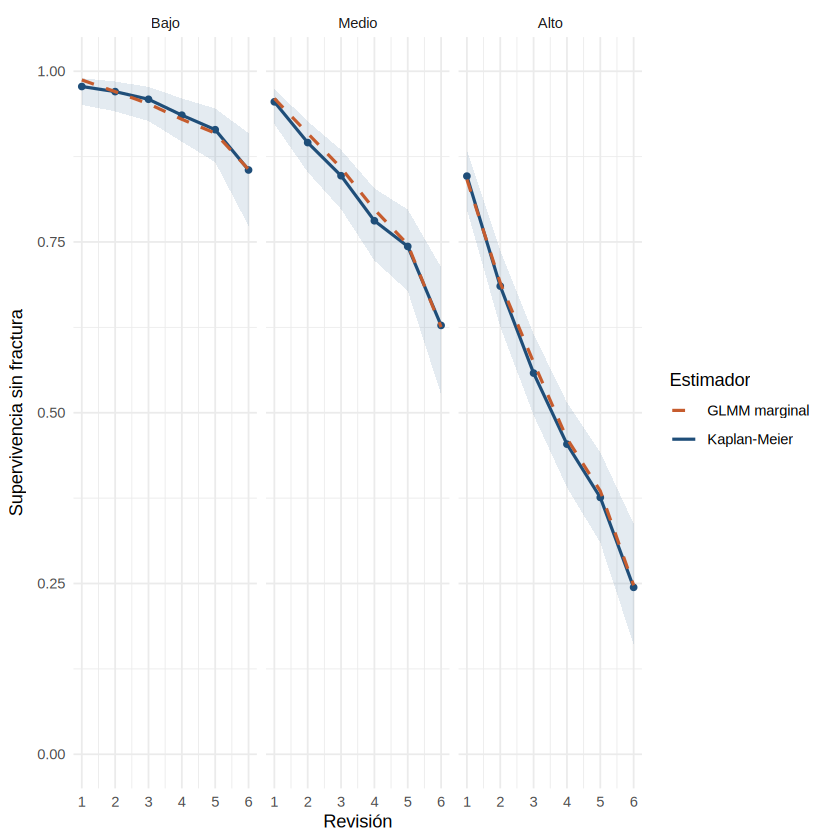

In [42]:
p2_proyeccion <- expand.grid(
        id = cohorte$id,
        periodo = factor(
                levels( pp$periodo ),
                levels = levels( pp$periodo )
            )
    ) |>
    left_join(
            cohorte |>
                select( id, x1, x2, centro ),
            by = "id"
        )

p2_proyeccion$eta_fijo <- predict(
        p2_clinica,
        newdata = p2_proyeccion,
        type = "link",
        re.form = NA
    )
p2_proyeccion <- p2_proyeccion |>
    arrange( id, periodo ) |>
    group_by( id ) |>
    mutate(
            intensidad_acumulada = cumsum( exp( eta_fijo ) )
        ) |>
    ungroup()

p2_sigma_centro <- as.numeric(
        attr(
                lme4::VarCorr( p2_clinica )$centro,
                "stddev"
            )[ 1 ]
    )
p2_cuadratura <- statmod::gauss.quad.prob(
        n = 21,
        dist = "normal",
        mu = 0,
        sigma = p2_sigma_centro
    )
p2_supervivencia_nodos <- exp(
        -outer(
                p2_proyeccion$intensidad_acumulada,
                exp( p2_cuadratura$nodes )
            )
    )
p2_proyeccion$supervivencia <- drop(
        p2_supervivencia_nodos %*% p2_cuadratura$weights
    )

p2_terciles <- cohorte |>
    select( id, tiempo, evento ) |>
    left_join(
            p2_proyeccion |>
                filter( periodo == "6" ) |>
                transmute(
                        id,
                        supervivencia6 = supervivencia,
                        riesgo6 = 1 - supervivencia
                    ),
            by = "id"
        ) |>
    mutate(
            tercil = factor(
                    c( "Bajo", "Medio", "Alto" )[
                        ntile( riesgo6, 3 )
                    ],
                    levels = c( "Bajo", "Medio", "Alto" )
                )
        )

p2_km_terciles <- survival::survfit(
        survival::Surv( tiempo, evento ) ~ tercil,
        data = p2_terciles,
        conf.type = "log-log"
    )
p2_km_resumen <- summary(
        p2_km_terciles,
        times = 1:6,
        extend = TRUE
    )
p2_km_tabla <- data.frame(
        tercil = factor(
                sub(
                        "^tercil=",
                        "",
                        as.character( p2_km_resumen$strata )
                    ),
                levels = levels( p2_terciles$tercil )
            ),
        periodo = factor(
                as.character( p2_km_resumen$time ),
                levels = levels( pp$periodo )
            ),
        km = p2_km_resumen$surv,
        km_inf = p2_km_resumen$lower,
        km_sup = p2_km_resumen$upper,
        en_riesgo = p2_km_resumen$n.risk
    )

p2_pred_terciles <- p2_proyeccion |>
    inner_join(
            p2_terciles |>
                select( id, tercil ),
            by = "id"
        ) |>
    group_by( tercil, periodo ) |>
    summarise(
            supervivencia_predicha = mean( supervivencia ),
            .groups = "drop"
        )

p2_cal_terciles <- left_join(
        p2_km_tabla,
        p2_pred_terciles,
        by = c( "tercil", "periodo" )
    )
print( p2_cal_terciles |>
    filter( periodo == "6" ) |>
    select(
            tercil,
            en_riesgo,
            km,
            km_inf,
            km_sup,
            supervivencia_predicha
        ) )

ggplot(
        p2_cal_terciles,
        aes( x = as.integer( periodo ) )
    ) +
    geom_ribbon(
            aes( ymin = km_inf, ymax = km_sup ),
            fill = "#4E79A7",
            alpha = 0.15
        ) +
    geom_line(
            aes( y = km, linetype = "Kaplan-Meier" ),
            color = "#1F4E79",
            linewidth = 0.9
        ) +
    geom_point(
            aes( y = km ),
            color = "#1F4E79"
        ) +
    geom_line(
            aes(
                    y = supervivencia_predicha,
                    linetype = "GLMM marginal"
                ),
            color = "#C65C2E",
            linewidth = 0.9
        ) +
    facet_wrap( ~ tercil ) +
    scale_x_continuous( breaks = 1:6 ) +
    scale_y_continuous( limits = c( 0, 1 ) ) +
    scale_linetype_manual(
            values = c(
                    "Kaplan-Meier" = "solid",
                    "GLMM marginal" = "dashed"
                )
        ) +
    labs(
            x = "Revisión",
            y = "Supervivencia sin fractura",
            linetype = "Estimador"
        ) +
    theme_minimal()



### Discriminación con censura: índice C

El índice C de Harrell mira si, entre dos mujeres cuyos tiempos se
pueden comparar, la de mayor riesgo predicho se fractura antes.
Respeta la censura. La puntuación es `1 - S_6` integrada sobre
clínicas: vale para una mujer de una clínica nueva, de la que aún
no sabemos el efecto. Lo calculamos en esta cohorte, así que es
**aparente** y puede pecar de optimista. No mide directamente cómo
irá en clínicas que no están aquí.



In [43]:
p2_indice_c <- survival::concordance(
        survival::Surv( tiempo, evento ) ~ riesgo6,
        data = p2_terciles,
        reverse = TRUE
    )
print( p2_indice_c )


Call:
concordance.formula(object = survival::Surv(tiempo, evento) ~ 
    riesgo6, data = p2_terciles, reverse = TRUE)

n= 803 
Concordance= 0.7817 se= 0.01551
concordant discordant     tied.x     tied.y    tied.xy 
    111432      31118          0       5870          0 



### Lectura de P2

La tasa observada es más alta en la revisión 6:
`r round(100*riesgo_periodo$hazard_observado[6], 1)` %,
pero ahí solo quedan `r riesgo_periodo$en_riesgo[6]` mujeres y el
intervalo se abre. No lo leemos como el momento en que el riesgo
se dispara para todas.

El GLMM cloglog da un HR de
`r round(efectos_clinica$efecto[efectos_clinica$termino=="x1"], 2)`
por unidad de fragilidad y de
`r round(efectos_clinica$efecto[efectos_clinica$termino=="x2"], 2)`
para el tratamiento, condicional a la clínica. Los IC están en la
tabla. Al meter la clínica, los errores estándar de `x1` y `x2`
pasan de
`r round(p2_compara_coef$se_pooled[1], 3)` y
`r round(p2_compara_coef$se_pooled[2], 3)` a
`r round(p2_compara_coef$se_clinica[1], 3)` y
`r round(p2_compara_coef$se_clinica[2], 3)`. Los coeficientes también
se mueven. El LRT de frontera deja clara una variación basal entre
clínicas (aproximado `p < 0,001`; el valor exacto está en la tabla).
Dejar que el efecto cambie por revisión no mejora
(LRT `p =`
`r signif(anova(p2_clinica, p2_variable, test="Chisq")[["Pr(>Chisq)"]][2], 3)`),
ni el término cuadrático de fragilidad
(LRT `p =`
`r signif(anova(p2_clinica, p2_cuadratico, test="Chisq")[["Pr(>Chisq)"]][2], 3)`).
El gráfico de martingala sirve para ver si queda alguna curva local
que ese contraste no cace. El logit ajusta casi igual por AIC, pero
`exp(beta)` sería un OR por revisión. Nos quedamos con cloglog
porque la pregunta está en hazards.

En la revisión 6, el tercil de riesgo alto tiene una supervivencia
Kaplan–Meier de
`r round(100*p2_cal_terciles$km[p2_cal_terciles$tercil=="Alto" & p2_cal_terciles$periodo=="6"], 1)` %
y una predicha de
`r round(100*p2_cal_terciles$supervivencia_predicha[p2_cal_terciles$tercil=="Alto" & p2_cal_terciles$periodo=="6"], 1)` %.
El índice C aparente es
`r round(p2_indice_c$concordance, 3)`
(EE `r round(sqrt(p2_indice_c$var), 3)`): ordena mejor que el azar.
Con eso no se decide mujer a mujer, ni se sabe cómo irá en clínicas
que no están en la cohorte.

Con `x1 = 1` y sin tratamiento, el riesgo acumulado es
`r round(100*p2_perfiles$riesgo_acumulado[p2_perfiles$x1==1 & p2_perfiles$x2==0 & p2_perfiles$periodo=="3"], 1)` %
a la revisión 3 y
`r round(100*p2_perfiles$riesgo_acumulado[p2_perfiles$x1==1 & p2_perfiles$x2==0 & p2_perfiles$periodo=="6"], 1)` %
a la 6. Con tratamiento,
`r round(100*p2_perfiles$riesgo_acumulado[p2_perfiles$x1==1 & p2_perfiles$x2==1 & p2_perfiles$periodo=="3"], 1)` %
y
`r round(100*p2_perfiles$riesgo_acumulado[p2_perfiles$x1==1 & p2_perfiles$x2==1 & p2_perfiles$periodo=="6"], 1)` %.
El riesgo acumulado sale más bajo en tratadas, en la dirección de
un retraso. Es una asociación del modelo, no una prueba de que el
tratamiento cause ese retraso.

En la escala que los datos identifican —revisiones, no días— el
hazard basal sube en conjunto y la supervivencia cae más al final,
justo donde los intervalos se abren por la censura y por quienes ya
se fracturaron. No hay motivo, en estas curvas, para saltarse las
revisiones 4 a 6, tampoco en tratadas, y la fragilidad alta concentra
riesgo desde el principio. Visitas entre revisión y revisión no salen
de este banco: haría falta un tiempo más fino.

## P3. ¿Qué factores se asocian al endotipo A, B o C?

`clase_nom` no tiene orden. Ajustamos una multinomial con A como
referencia, y entran **todas** las mujeres. Para B y para C,
`exp(beta)` multiplica `P(categoría) / P(A)` cuando la covariable
sube una unidad y la otra se queda quieta. No es el cociente de
probabilidades entre dos pacientes.

Los IC de Wald de abajo asumen independencia. Luego evaluamos si
la predicción viaja a clínicas que no entraron en el ajuste. Eso
no cubre cualquier dependencia que quede entre pacientes.



In [44]:
m_nominal_nulo <- nnet::multinom(
        clase_nom ~ 1,
        data = cohorte,
        trace = FALSE,
        Hess = TRUE
    )
m_nominal <- nnet::multinom(
        clase_nom ~ x1 + x2,
        data = cohorte,
        trace = FALSE,
        Hess = TRUE,
        maxit = 500
    )

stopifnot( "El multinomial no converge." = m_nominal$convergence == 0 )
tabla_modelos( nulo = m_nominal_nulo, covariables = m_nominal )
anova( m_nominal_nulo, m_nominal, test = "Chisq" )

estadistico_nominal <- 2 * (
        as.numeric( logLik( m_nominal ) ) -
            as.numeric( logLik( m_nominal_nulo ) )
    )
grados_nominal <- attr( logLik( m_nominal ), "df" ) -
    attr( logLik( m_nominal_nulo ), "df" )
print( data.frame(
        LRT = estadistico_nominal,
        gl = grados_nominal,
        p = pchisq(
                estadistico_nominal,
                df = grados_nominal,
                lower.tail = FALSE
            )
    ) )


modelo,AIC,BIC,logLik,n
<chr>,<dbl>,<dbl>,<dbl>,<int>
nulo,1723.857,1733.234,-859.9287,803
covariables,1582.827,1610.957,-785.4133,803


Model,Resid. df,Resid. Dev,Test,Df,LR stat.,Pr(Chi)
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,1604,1719.857,,NA,NA,NA
x1 + x2,1600,1570.827,1 vs 2,4,149.0309,0


       LRT gl            p
1 149.0309  4 3.283806e-31


In [45]:
resumen_nominal <- summary( m_nominal )
coef_nominal <- resumen_nominal$coefficients
error_nominal <- resumen_nominal$standard.errors

efectos_nominales <- expand.grid(
        categoria = rownames( coef_nominal ),
        termino = colnames( coef_nominal ),
        stringsAsFactors = FALSE
    )
efectos_nominales$beta <- as.vector( coef_nominal )
efectos_nominales$error <- as.vector( error_nominal )

efectos_nominales <- efectos_nominales |>
    mutate(
            OR_relativa = exp( beta ),
            inferior = exp( beta - qnorm( 0.975 ) * error ),
            superior = exp( beta + qnorm( 0.975 ) * error ),
            p = 2 * pnorm( abs( beta / error ), lower.tail = FALSE )
        )

efectos_nominales


categoria,termino,beta,error,OR_relativa,inferior,superior,p
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B,(Intercept),-0.3954120,0.1207220,0.6734025,0.5315156,0.8531660,1.055152e-03
C,(Intercept),-0.5995922,0.1300990,0.5490355,0.4254611,0.7085018,4.051240e-06
B,x1,0.8165309,0.1063831,2.2626368,1.8367980,2.7872011,1.649268e-14
C,x1,1.0526105,0.1064104,2.8651207,2.3257670,3.5295525,4.509917e-23
B,x2,-0.1319326,0.1880172,0.8764001,0.6062642,1.2669017,4.828632e-01
C,x2,0.5950922,0.1812035,1.8131981,1.2711726,2.5863422,1.023054e-03



### Probabilidades para perfiles comparables

Comparamos `x1 = -1, 0, 1`, con y sin tratamiento. Son predicciones
puntuales: los IC de arriba son de los efectos, no de estas
probabilidades. En cada perfil, las tres tienen que sumar uno.



,x1,x2,clase_mas_probable,A,B,C
,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
1,-1,0,A,0.6714808,0.1998451,0.1286741
2,0,0,A,0.4499563,0.3030017,0.2470420
3,1,0,C,0.2440978,0.3719234,0.3839788
4,-1,1,A,0.6217779,0.1621801,0.2160419
5,0,1,A,0.3867454,0.2282456,0.3850090
6,1,1,C,0.1927675,0.2574102,0.5498223


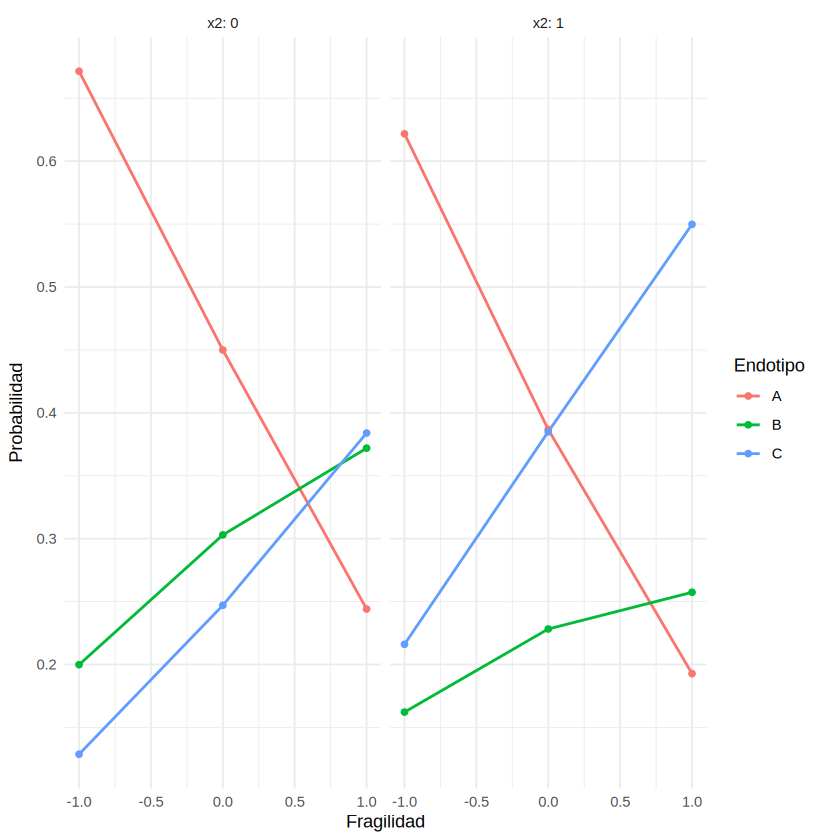

In [46]:
perfiles_nominales <- expand.grid(
        x1 = c( -1, 0, 1 ),
        x2 = c( 0, 1 )
    )
prob_nominales <- predict(
        m_nominal,
        newdata = perfiles_nominales,
        type = "probs"
    )
stopifnot( max( abs( rowSums( prob_nominales ) - 1 ) ) < 1e-8 )
perfiles_nominales$clase_mas_probable <- predict(
        m_nominal,
        newdata = perfiles_nominales,
        type = "class"
    )
cbind( perfiles_nominales, prob_nominales )

grafico_nominal <- cbind( perfiles_nominales, prob_nominales ) |>
    pivot_longer(
            cols = all_of( colnames( prob_nominales ) ),
            names_to = "categoria",
            values_to = "probabilidad"
        )

ggplot(
        grafico_nominal,
        aes( x = x1, y = probabilidad, color = categoria )
    ) +
    geom_line( linewidth = 0.8 ) +
    geom_point() +
    facet_wrap( ~ x2, labeller = label_both ) +
    labs( x = "Fragilidad", y = "Probabilidad", color = "Endotipo" ) +
    theme_minimal()



### Evaluación fuera de muestra

Cinco particiones, cada una con **clínicas enteras**, y la fórmula
aditiva fijada antes de evaluar. En un pliegue, ninguna paciente de
las clínicas de prueba entra en el ajuste. La referencia predice
siempre la categoría modal del entrenamiento, no la que saldría
calculándola con la prueba.

La exactitud cuenta aciertos. La pérdida logarítmica mira las
probabilidades y castiga más un error dicho con mucha seguridad.
Estas cifras describen este esquema. No dicen cómo iría en otra
población.



In [47]:
set.seed( 260927 )
centros_nominal <- unique( as.character( cohorte$centro ) )
pliegues_nominal <- setNames(
        sample( rep( 1:5, length.out = length( centros_nominal ) ) ),
        centros_nominal
    )
fold_nominal <- unname(
        pliegues_nominal[ as.character( cohorte$centro ) ]
    )

prob_fuera_nominal <- matrix(
        NA_real_,
        nrow = nrow( cohorte ),
        ncol = 3,
        dimnames = list( NULL, levels( cohorte$clase_nom ) )
    )
modal_fuera_nominal <- character( nrow( cohorte ) )
prob_base_nominal <- prob_fuera_nominal


In [48]:
for ( k in 1:5 ) {
    prueba <- fold_nominal == k
    entrenamiento <- cohorte[ !prueba, ]
    ajuste <- nnet::multinom(
            clase_nom ~ x1 + x2,
            data = entrenamiento,
            trace = FALSE,
            maxit = 500
        )
    stopifnot( "No converge un pliegue nominal." = ajuste$convergence == 0 )
    prob_fuera_nominal[ prueba, ] <- predict(
            ajuste,
            newdata = cohorte[ prueba, ],
            type = "probs"
        )
    frecuencias <- prop.table( table( entrenamiento$clase_nom ) )
    modal_fuera_nominal[ prueba ] <- names( which.max( frecuencias ) )
    prob_base_nominal[ prueba, ] <- matrix(
            rep( as.numeric( frecuencias ), each = sum( prueba ) ),
            ncol = 3
        )
    }

clase_predicha <- colnames( prob_fuera_nominal )[
    max.col( prob_fuera_nominal, ties.method = "first" )
    ]
indices_reales <- cbind(
        seq_len( nrow( cohorte ) ),
        as.integer( cohorte$clase_nom )
    )
data.frame(
        modelo = c( "Multinomial", "Referencia entrenamiento" ),
        exactitud = c(
                mean( clase_predicha == cohorte$clase_nom ),
                mean( modal_fuera_nominal == cohorte$clase_nom )
            ),
        log_loss = c(
                -mean( log( pmax( prob_fuera_nominal[ indices_reales ], 1e-15 ) ) ),
                -mean( log( pmax( prob_base_nominal[ indices_reales ], 1e-15 ) ) )
            )
    )
table( Observado = cohorte$clase_nom, Predicho = clase_predicha )
table(
        Observado = cohorte$clase_nom,
        Predicho_modal = factor(
                modal_fuera_nominal,
                levels = levels( cohorte$clase_nom )
            )
    )


modelo,exactitud,log_loss
<chr>,<dbl>,<dbl>
Multinomial,0.5193026,0.9865996
Referencia entrenamiento,0.4408468,1.0746491


         Predicho
Observado   A   B   C
        A 283  17  54
        B 114  12  76
        C 107  18 122

         Predicho_modal
Observado   A   B   C
        A 354   0   0
        B 202   0   0
        C 247   0   0


### Lectura de P3

Por cada unidad de fragilidad, las odds B/A se multiplican por
`r round(efectos_nominales$OR_relativa[efectos_nominales$categoria=="B" & efectos_nominales$termino=="x1"], 2)`
y las C/A por
`r round(efectos_nominales$OR_relativa[efectos_nominales$categoria=="C" & efectos_nominales$termino=="x1"], 2)`.
El tratamiento sube el cociente C/A
(OR
`r round(efectos_nominales$OR_relativa[efectos_nominales$categoria=="C" & efectos_nominales$termino=="x2"], 2)`
);
en B/A el IC incluye el 1. Otra vez: eso no es una razón de
probabilidades entre dos mujeres. Sin tratamiento y con `x1 = -1`,
lo más probable es
`r as.character(perfiles_nominales$clase_mas_probable[perfiles_nominales$x1==-1 & perfiles_nominales$x2==0])`;
con `x1 = 1` y sin tratamiento,
`r as.character(perfiles_nominales$clase_mas_probable[perfiles_nominales$x1==1 & perfiles_nominales$x2==0])`.
En la tabla están las tres probabilidades, no solo la etiqueta.

Fuera de las clínicas de entrenamiento, la exactitud es
`r round(100*mean(clase_predicha==cohorte$clase_nom), 1)` %,
y la de decir siempre la categoría modal del entrenamiento,
`r round(100*mean(modal_fuera_nominal==cohorte$clase_nom), 1)` %.
De los casos B acierta
`r sum(clase_predicha=="B" & cohorte$clase_nom=="B")`
de
`r sum(cohorte$clase_nom=="B")`.
Las probabilidades orientan; asignar el endotipo mujer a mujer,
con estos aciertos, no.

## P4. ¿Qué se asocia a estadios más avanzados?

El orden es Leve < Moderado < Grave. Empezamos con un `clm` y
luego un `clmm` con intercepto por clínica. En `ordinal`,
`logit[P(Y <= j)] = umbral_j - eta`: un coeficiente positivo
empuja probabilidad hacia estadios **más graves**.

Así, `exp(beta)` multiplica las odds de pasar cada umbral, si la
proporcionalidad se sostiene. Tratamiento y estadio se anotaron a
la vez, al inicio. La asociación no dice que el tratamiento haya
cambiado el estadio.



In [49]:
m_ordinal <- ordinal::clm(
        sever_ord ~ x1 + x2,
        data = cohorte,
        link = "logit",
        Hess = TRUE
    )
m_ordinal_mixto <- ordinal::clmm(
        sever_ord ~ x1 + x2 + ( 1 | centro ),
        data = cohorte,
        link = "logit",
        Hess = TRUE,
        nAGQ = 7
    )

tabla_modelos( sin_centro = m_ordinal, con_centro = m_ordinal_mixto )
tabla_efectos( m_ordinal )
tabla_efectos( m_ordinal_mixto )
ordinal::VarCorr( m_ordinal_mixto )


modelo,AIC,BIC,logLik,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
sin_centro,1583.371,1602.125,-787.6857,803
con_centro,1550.977,1574.419,-770.4884,803


termino,beta,error,efecto,inferior,superior,p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
x1,0.9600797,0.0796968,2.6119046,2.2341857,3.0534818,2.019854e-33
x2,-0.4190318,0.1376292,0.6576833,0.5021883,0.8613249,2.329568e-03


termino,beta,error,efecto,inferior,superior,p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
x1,0.9992270,0.08304867,2.7161815,2.3081691,3.1963177,2.417565e-33
x2,-0.4272929,0.14189009,0.6522725,0.4939147,0.8614025,2.600154e-03


,(Intercept)
(Intercept),0.3247426



### Estabilidad y proporcionalidad

Miramos el código del optimizador, el gradiente y la curvatura, y
comparamos Laplace con siete puntos de cuadratura. El AIC no
autoriza un chi-cuadrado ordinario para una varianza que parte de
cero: ese valor está en la frontera.

`nominal_test()` vale para `clm`, no para `clmm`. Además del modelo
sin clínicas, repetimos la prueba con las clínicas como efectos
fijos. Esa segunda prueba recoge que unas clínicas parten de otro
nivel; no cubre ella sola los supuestos del mixto. Si saliera
en contra de las odds proporcionales, habría que reabrir el modelo
antes de cerrar la lectura.



In [50]:
m_ordinal_laplace <- update( m_ordinal_mixto, nAGQ = 1 )

data.frame(
        termino = names( m_ordinal_mixto$beta ),
        laplace = unname( m_ordinal_laplace$beta ),
        cuadratura_7 = unname( m_ordinal_mixto$beta )
    )
m_ordinal_mixto$optRes

autovalores <- eigen(
        m_ordinal_mixto$Hessian,
        symmetric = TRUE,
        only.values = TRUE
    )$values
data.frame(
        gradiente_maximo = max( abs( m_ordinal_mixto$gradient ) ),
        hessiano_positivo = all( autovalores > 0 ),
        condicion_hessiano = max( autovalores ) / min( autovalores )
    )


termino,laplace,cuadratura_7
<chr>,<dbl>,<dbl>
x1,0.9992907,0.9992270
x2,-0.4273417,-0.4272929


$par
[1] -0.9142338  0.6279347  0.9992270 -0.4272929 -0.5623612

$objective
[1] 770.4884

$convergence
[1] 0

$iterations
[1] 24

$evaluations
function gradient 
      32      177 

$message
[1] "relative convergence (4)"

gradiente_maximo,hessiano_positivo,condicion_hessiano
<dbl>,<lgl>,<dbl>
0.001273186,TRUE,14.42157


In [51]:
ordinal::nominal_test( m_ordinal )

m_ordinal_centros_fijos <- ordinal::clm(
        sever_ord ~ x1 + x2 + centro,
        data = cohorte,
        link = "logit"
    )
ordinal::nominal_test(
        m_ordinal_centros_fijos,
        scope = ~ x1 + x2
    )


,Df,logLik,AIC,LRT,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
<none>,NA,-787.6857,1583.371,NA,NA
x1,1,-787.6857,1585.371,2.338459e-06,0.9987799
x2,1,-787.6816,1585.363,8.273321e-03,0.9275261


,Df,logLik,AIC,LRT,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
<none>,NA,-742.6046,1539.209,NA,NA
x1,1,-742.6043,1541.209,0.0005005395,0.9821506
x2,1,-742.5331,1541.066,0.1429453498,0.7053703



### Del modelo a probabilidades por estadio

Las probabilidades salen de los umbrales del mixto. Fijamos el
efecto de clínica en `u = 0`: es el perfil de una clínica en el
centro de la escala del predictor, no el promedio de todas.

La misma función admite los efectos ya estimados de clínicas
conocidas, para una calibración aparente. Usa los datos del ajuste,
así que no es una evaluación fuera de muestra.



In [52]:
probabilidades_ordinales <- function(
        modelo,
        datos,
        efecto_centro = 0
    ) {
    diseno <- model.matrix( ~ x1 + x2, data = datos )
    eta <- drop(
            diseno[ , names( modelo$beta ), drop = FALSE ] %*%
                modelo$beta
        ) + efecto_centro
    primera <- plogis( modelo$alpha[ 1 ] - eta )
    segunda <- plogis( modelo$alpha[ 2 ] - eta )

    probabilidades <- cbind(
            Leve = primera,
            Moderado = segunda - primera,
            Grave = 1 - segunda
        )
    stopifnot(
            "Probabilidades ordinales invalidas." =
                all( probabilidades >= 0 ),
            "Las probabilidades no suman uno." =
                max( abs( rowSums( probabilidades ) - 1 ) ) < 1e-8
        )
    probabilidades
    }


,x1,x2,Leve,Moderado,Grave
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1,0,0.5212355,0.3145449,0.1642195
2,0,0,0.2861343,0.3658868,0.3479790
3,1,0,0.1285925,0.2796362,0.5917712
4,-1,1,0.6253422,0.2610547,0.1136030
5,0,1,0.3806145,0.3611630,0.2582225
6,1,1,0.1844976,0.3294989,0.4860035


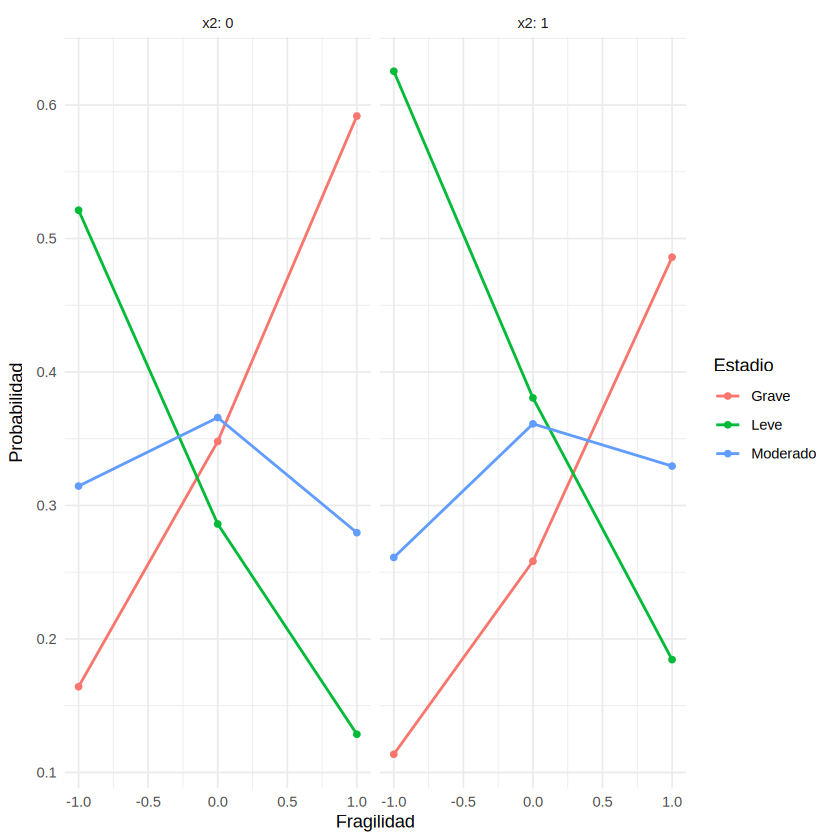

In [53]:
perfiles_ordinales <- expand.grid(
        x1 = c( -1, 0, 1 ),
        x2 = c( 0, 1 )
    )
prob_ordinales <- probabilidades_ordinales(
        m_ordinal_mixto,
        perfiles_ordinales
    )
cbind( perfiles_ordinales, prob_ordinales )

grafico_ordinal <- cbind( perfiles_ordinales, prob_ordinales ) |>
    pivot_longer(
            cols = c( Leve, Moderado, Grave ),
            names_to = "estadio",
            values_to = "probabilidad"
        )
ggplot(
        grafico_ordinal,
        aes( x = x1, y = probabilidad, color = estadio )
    ) +
    geom_line( linewidth = 0.8 ) +
    geom_point() +
    facet_wrap( ~ x2, labeller = label_both ) +
    labs( x = "Fragilidad", y = "Probabilidad", color = "Estadio" ) +
    theme_minimal()


In [54]:
efectos_centros_ordinal <- ordinal::ranef( m_ordinal_mixto )$centro
u_ordinal <- efectos_centros_ordinal[
    as.character( cohorte$centro ), 1
    ]
prob_ordinal_ajuste <- probabilidades_ordinales(
        m_ordinal_mixto,
        cohorte,
        efecto_centro = u_ordinal
    )

data.frame(
        estadio = levels( cohorte$sever_ord ),
        proporcion_observada = as.numeric(
                prop.table( table( cohorte$sever_ord ) )
            ),
        probabilidad_media_ajustada = colMeans( prob_ordinal_ajuste )
    )

calibracion_grave <- data.frame(
        observado = as.integer( cohorte$sever_ord == "Grave" ),
        predicho = prob_ordinal_ajuste[ , "Grave" ]
    ) |>
    mutate( grupo = ntile( predicho, 8 ) ) |>
    group_by( grupo ) |>
    summarise(
            n = n(),
            observado = mean( observado ),
            predicho = mean( predicho ),
            .groups = "drop"
        )
calibracion_grave


,estadio,proporcion_observada,probabilidad_media_ajustada
,<chr>,<dbl>,<dbl>
Leve,Leve,0.3711083,0.3684594
Moderado,Moderado,0.2914072,0.2954729
Grave,Grave,0.3374844,0.3360676


grupo,n,observado,predicho
<int>,<int>,<dbl>,<dbl>
1,101,0.03960396,0.0709732
2,101,0.13861386,0.1277031
3,101,0.15841584,0.1918464
4,100,0.25000000,0.2581597
5,100,0.35000000,0.3355498
6,100,0.51000000,0.4280080
7,100,0.46000000,0.5444093
8,100,0.80000000,0.7380686



### Lectura de P4

En el ordinal mixto, una unidad más de fragilidad multiplica por
`r round(exp(m_ordinal_mixto$beta["x1"]), 2)` las odds de estar
por encima de cualquiera de los dos umbrales. El OR acumulado del
tratamiento es
`r round(exp(m_ordinal_mixto$beta["x2"]), 2)`, hacia estadios menos
graves. Los IC están en la tabla. Con `x1 = 0` y efecto de clínica
cero, la probabilidad de estadio grave pasa de
`r round(100*prob_ordinales[perfiles_ordinales$x1==0 & perfiles_ordinales$x2==0,"Grave"], 1)` %
sin tratamiento a
`r round(100*prob_ordinales[perfiles_ordinales$x1==0 & perfiles_ordinales$x2==1,"Grave"], 1)` %
con él. Las dos variables se midieron al inicio: no es que el
tratamiento haya bajado un estadio ya anotado.

En el `clm` no vemos odds no proporcionales ni en `x1` ni en `x2`,
y la prueba con centros fijos va en la misma dirección. No hay un
equivalente hecho directamente sobre el `clmm`. El mixto baja el
AIC respecto al `clm`, y la cuadratura deja efectos muy parecidos
a Laplace. El optimizador devuelve código cero y un mensaje de
convergencia relativa: el ajuste arranca, pero no lo daría por
cerrado sin esa sensibilidad. La calibración usa los mismos datos
con los que se ajustó. El estadio que importa es el observado al
inicio; de esta asociación no se sigue que el tratamiento lo reduzca.

## P5. ¿Cuánto depende de la clínica?

Sobre `cohorte` comparamos tres logísticas con los mismos efectos
fijos: la aditiva, un intercepto aleatorio por clínica, y ese
intercepto más una pendiente aleatoria de fragilidad. Así la
comparación es de la parte aleatoria. Como sensibilidad, la
interacción de P1 se añade al modelo de solo intercepto.

Siguen siendo modelos de `ever`, con ventanas de distinta duración.
Para el riesgo en un plazo concreto manda P2. Lo que queda entre
centros puede ser composición de pacientes o algo no medido. No
identifica, por sí solo, qué clínica atiende mejor.



In [55]:
p5_control <- lme4::glmerControl(
        optimizer = "bobyqa",
        optCtrl = list( maxfun = 200000 )
    )
p5_ri <- lme4::glmer(
        ever ~ x1 + x2 + (1 | centro),
        data = cohorte,
        family = binomial(),
        control = p5_control
    )
p5_rs <- lme4::glmer(
        ever ~ x1 + x2 + (1 + x1 | centro),
        data = cohorte,
        family = binomial(),
        control = p5_control
    )
p5_interaccion <- lme4::glmer(
        ever ~ x1 * x2 + (1 | centro),
        data = cohorte,
        family = binomial(),
        control = p5_control
    )
print( tabla_modelos(
        pooled = p1_aditivo,
        intercepto = p5_ri,
        pendiente = p5_rs,
        interaccion = p5_interaccion
    ) )


boundary (singular) fit: see help('isSingular')



       modelo      AIC      BIC    logLik   n
1      pooled 776.4479 790.5130 -385.2240 803
2  intercepto 755.3058 774.0592 -373.6529 803
3   pendiente 759.2747 787.4048 -373.6373 803
4 interaccion 756.6294 780.0711 -373.3147 803



### Efectos agrupados y condicionados a la clínica

Los dos modelos llevan las mismas covariables, así que la tabla
compara coeficiente, error estándar y OR. El *pooled* resume la
asociación en la mezcla de clínicas. El GLMM la condiciona al
intercepto de una clínica. Que los coeficientes no coincidan también
viene de que el OR logístico no es colapsable: esa diferencia, sola,
no es un sesgo causal del *pooled*.



In [56]:
p5_coef_pooled <- coef( summary( p1_aditivo ) )
p5_coef_ri <- coef( summary( p5_ri ) )
stopifnot( identical(
        rownames( p5_coef_pooled ),
        rownames( p5_coef_ri )
    ) )
p5_comparacion_coef <- data.frame(
        termino = rownames( p5_coef_pooled ),
        beta_pooled = p5_coef_pooled[ , "Estimate" ],
        error_pooled = p5_coef_pooled[ , "Std. Error" ],
        OR_pooled = exp( p5_coef_pooled[ , "Estimate" ] ),
        beta_condicional = p5_coef_ri[ , "Estimate" ],
        error_condicional = p5_coef_ri[ , "Std. Error" ],
        OR_condicional = exp( p5_coef_ri[ , "Estimate" ] )
    )
print(
        p5_comparacion_coef,
        digits = 3,
        row.names = FALSE
    )


     termino beta_pooled error_pooled OR_pooled beta_condicional error_condicional
 (Intercept)      -0.812        0.121     0.444           -0.880             0.189
          x1       1.401        0.116     4.061            1.456             0.124
          x2      -0.500        0.180     0.607           -0.578             0.190
 OR_condicional
          0.415
          4.288
          0.561



### Estabilidad, varianzas e interacción

Una pendiente aleatoria pide variación que se pueda estimar,
convergencia y un ajuste que no sea singular. Si la correlación se
pega a ±1, la varianza de la pendiente es casi cero, o el ajuste
es singular, la estructura le queda grande a estos datos. Miramos
también AIC, BIC y para qué queremos el modelo. No elegimos por
un solo número.

El p-valor chi-cuadrado habitual **no vale** para añadir una
varianza aleatoria: la hipótesis nula está en la frontera. En los
dos saltos usamos las mezclas de chi-cuadrado de la unidad 4. Si
la pendiente es singular, se descarta aunque el contraste diga
otra cosa. La interacción fija sí se contrasta con el chi-cuadrado
de siempre. El ICC de abajo es **latente y del modelo de solo
intercepto**. No es el porcentaje de fracturas que «explica» la
clínica. Si hubiera pendiente aleatoria, esa dependencia cambiaría
con `x1`.



In [57]:
for ( nombre in c( "p5_ri", "p5_rs", "p5_interaccion" ) ) {
    modelo <- get( nombre )
    cat( "\n", nombre, "\n" )
    print( lme4::VarCorr( modelo ) )
    print( list(
            singular = lme4::isSingular( modelo, tol = 1e-4 ),
            codigo_optimizador = modelo@optinfo$conv$opt,
            mensajes = modelo@optinfo$conv$lme4$messages
        ) )
    }
p5_varianza <- as.numeric( lme4::VarCorr( p5_ri )$centro[ 1, 1 ] )
print( data.frame(
        varianza_centro = p5_varianza,
        ICC_latente_RI = p5_varianza / (p5_varianza + pi^2 / 3)
    ) )
p5_lr_intercepto <- as.numeric(
        2 * ( logLik( p5_ri ) - logLik( p1_aditivo ) )
    )
p5_lr_pendiente <- as.numeric(
        2 * ( logLik( p5_rs ) - logLik( p5_ri ) )
    )
p5_p_intercepto <- 0.5 * pchisq(
        p5_lr_intercepto,
        df = 1,
        lower.tail = FALSE
    )
p5_p_pendiente <-
    0.5 * pchisq(
            p5_lr_pendiente,
            df = 1,
            lower.tail = FALSE
        ) +
    0.5 * pchisq(
            p5_lr_pendiente,
            df = 2,
            lower.tail = FALSE
        )
print( data.frame(
        salto = c( "pooled → intercepto", "intercepto → pendiente" ),
        chi2 = c( p5_lr_intercepto, p5_lr_pendiente ),
        p_frontera = c( p5_p_intercepto, p5_p_pendiente )
    ) )
print( anova(
        p5_ri,
        p5_interaccion,
        test = "Chisq"
    ) )
print( tabla_efectos( p5_ri ) )
print( tabla_efectos( p5_interaccion ) )



 p5_ri 
 Groups Name        Std.Dev.
 centro (Intercept) 0.68259 
$singular
[1] FALSE

$codigo_optimizador
[1] 0

$mensajes
NULL


 p5_rs 
 Groups Name        Std.Dev. Corr  
 centro (Intercept) 0.67640        
        x1          0.02564  1.000 
$singular
[1] TRUE

$codigo_optimizador
[1] 0

$mensajes
[1] "boundary (singular) fit: see help('isSingular')"


 p5_interaccion 
 Groups Name        Std.Dev.
 centro (Intercept) 0.6842  
$singular
[1] FALSE

$codigo_optimizador
[1] 0

$mensajes
NULL

  varianza_centro ICC_latente_RI
1       0.4659302      0.1240562
                   salto        chi2   p_frontera
1    pooled → intercepto 23.14210123 7.522999e-07
2 intercepto → pendiente  0.03116055 9.222116e-01
Data: cohorte
Models:
p5_ri: ever ~ x1 + x2 + (1 | centro)
p5_interaccion: ever ~ x1 * x2 + (1 | centro)
               npar    AIC    BIC  logLik -2*log(L)  Chisq Df Pr(>Chisq)
p5_ri             4 755.31 774.06 -373.65    747.31                     
p5_interaccion    5 756.63 780.07


El \(R^2\) marginal recoge lo que aportan `x1` y `x2`. El
condicional le suma el intercepto de clínica. Los dos viven en la
escala latente del GLMM logístico, no en «porcentaje de fracturas
acertadas». Su diferencia es el extra del agrupamiento después de
los efectos fijos, y por eso no tiene por qué coincidir con el ICC
de arriba.



In [58]:
p5_r2 <- performance::r2( p5_ri )
print( p5_r2 )
p5_r2_marginal <- as.numeric( p5_r2$R2_marginal )
p5_r2_condicional <- as.numeric( p5_r2$R2_conditional )
stopifnot(
        length( p5_r2_marginal ) == 1,
        length( p5_r2_condicional ) == 1,
        is.finite( p5_r2_marginal ),
        is.finite( p5_r2_condicional )
    )
print( data.frame(
        R2_marginal = p5_r2_marginal,
        R2_condicional = p5_r2_condicional,
        aporte_clinica = p5_r2_condicional - p5_r2_marginal
    ) )


# R2 for Mixed Models

  Conditional R2: 0.440
     Marginal R2: 0.361
  R2_marginal R2_condicional aporte_clinica
1    0.360967       0.440243     0.07927604


DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details

DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details



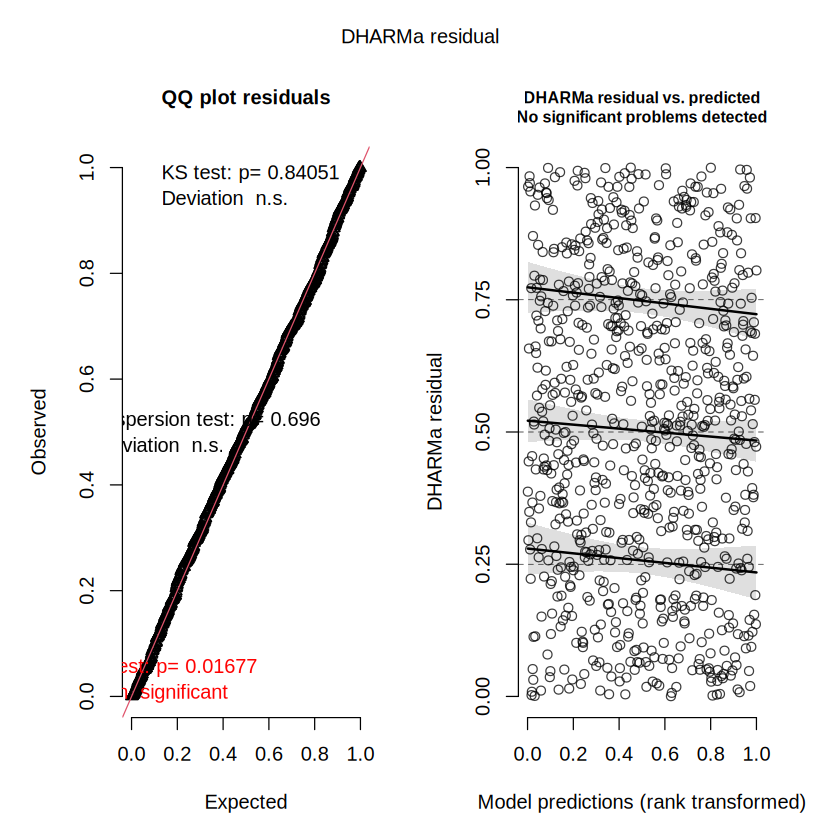


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  simulationOutput$scaledResiduals
D = 0.021786, p-value = 0.8405
alternative hypothesis: two-sided


	DHARMa nonparametric dispersion test via sd of residuals fitted vs. simulated

data:  simulationOutput
dispersion = 1.0149, p-value = 0.696
alternative hypothesis: two.sided



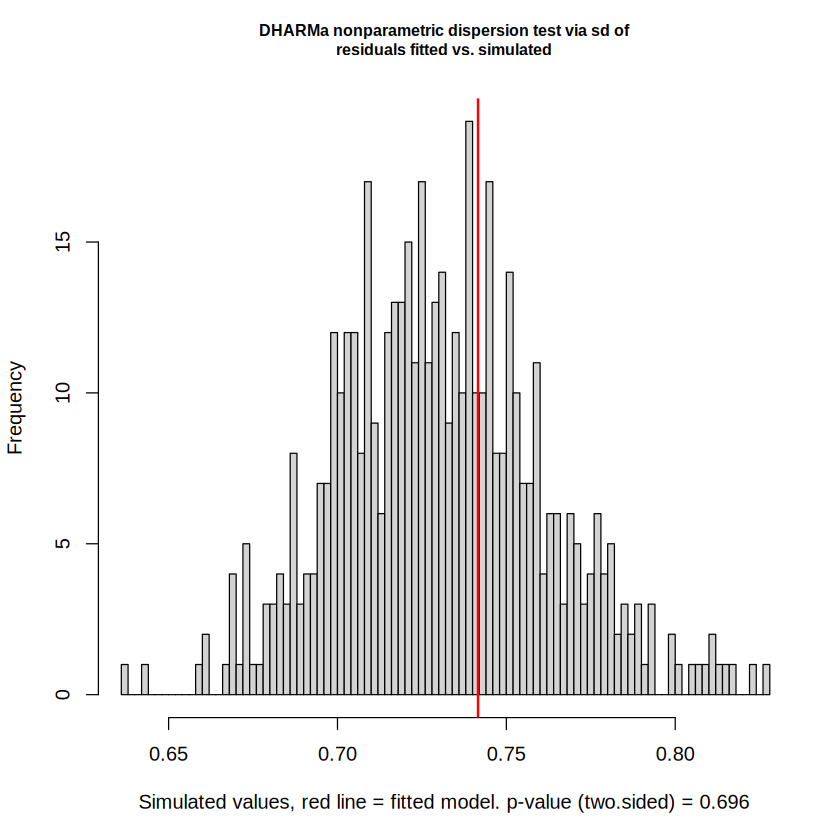

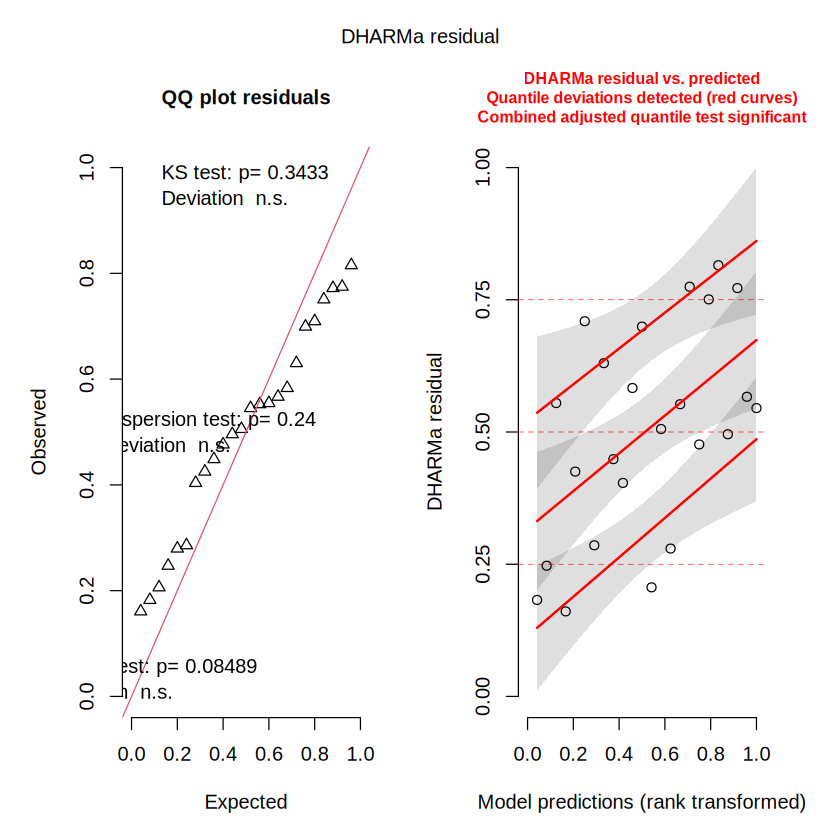

In [59]:
p5_residuos <- DHARMa::simulateResiduals(
        fittedModel = p5_ri,
        n = 500,
        seed = 51926
    )
plot( p5_residuos )
p5_test_uniformidad <- DHARMa::testUniformity(
        p5_residuos,
        plot = FALSE
    )
p5_test_dispersion <- DHARMa::testDispersion( p5_residuos )
print( p5_test_uniformidad )
print( p5_test_dispersion )
p5_residuos_centro <- DHARMa::recalculateResiduals(
        p5_residuos,
        group = cohorte$centro
    )
plot( p5_residuos_centro )


  p_homogeneidad_residuos centros_no_uniformes_ajustados
1               0.2055563                              0


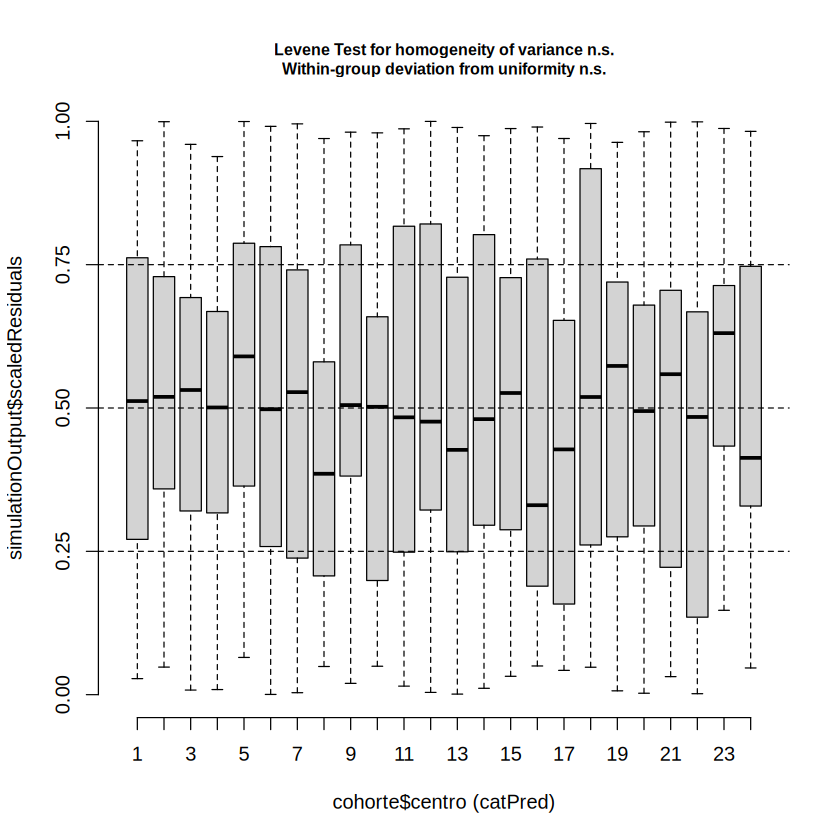

In [60]:
p5_prueba_centros <- DHARMa::testCategorical(
        p5_residuos,
        catPred = cohorte$centro,
        plot = TRUE
    )
p5_p_homogeneidad <- p5_prueba_centros$homogeneity[[ "Pr(>F)" ]][ 1 ]
print( data.frame(
        p_homogeneidad_residuos = p5_p_homogeneidad,
        centros_no_uniformes_ajustados = sum(
                p5_prueba_centros$uniformity$p.value.cor < 0.05
            )
    ) )



### Diferencias ajustadas y contracción de las estimaciones

Dibujamos el intercepto de cada clínica con un intervalo condicional
aproximado. El estimador parcial encoge hacia cero a los centros
con poca información, y por eso una tasa bruta extrema no se lee
como una diferencia ya medida.

Esos intervalos condicionan a los parámetros estimados del modelo.
**No** son 24 comparaciones simultáneas. Si uno no incluye el cero,
esa clínica merece una mirada; no queda demostrado que atienda
mejor o peor. El orden del gráfico es para leerlo, no un ranking.



   centro  intercepto     error   inferior    superior
1       1 -0.51354915 0.3936497 -1.2851025  0.25800421
2       2  0.47558301 0.3735133 -0.2565031  1.20766916
3       3  0.19483873 0.3755457 -0.5412309  0.93090839
4       4 -0.14918756 0.3580141 -0.8508952  0.55252010
5       5 -0.06068685 0.3900510 -0.8251868  0.70381305
6       6 -0.55336709 0.3946753 -1.3269306  0.22019643
7       7 -0.57746958 0.4312086 -1.4226385  0.26769932
8       8 -0.92142861 0.4465626 -1.7966912 -0.04616598
9       9  0.24109414 0.3213580 -0.3887676  0.87095591
10     10 -0.63167155 0.3947861 -1.4054524  0.14210925
11     11 -0.40356989 0.3993074 -1.1862124  0.37907261
12     12  0.49565263 0.3692089 -0.2279968  1.21930201
13     13 -0.27397431 0.4112804 -1.0800839  0.53213527
14     14  0.80615359 0.3545701  0.1111962  1.50111103
15     15  0.12521275 0.3605536 -0.5814724  0.83189790
16     16 -0.98615474 0.4521347 -1.8723388 -0.09997066
17     17 -0.03353267 0.4135859 -0.8441610  0.77709563
18     18 

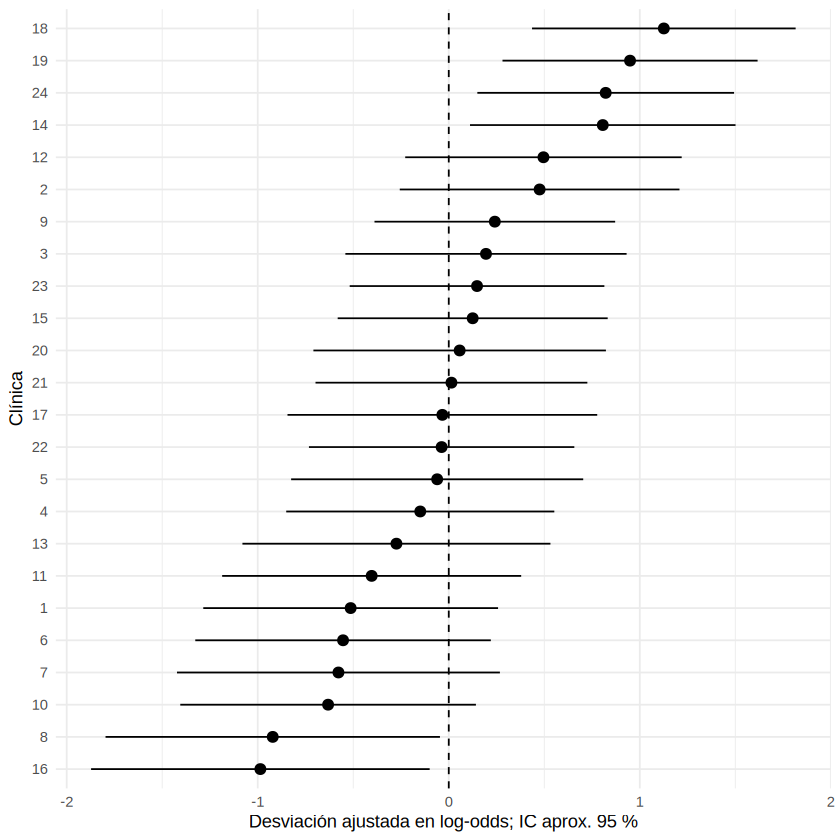

In [61]:
p5_aleatorios <- lme4::ranef(
        p5_ri,
        condVar = TRUE
    )$centro
p5_centros <- data.frame(
        centro = rownames( p5_aleatorios ),
        intercepto = p5_aleatorios[[ 1 ]],
        error = sqrt( attr( p5_aleatorios, "postVar" )[ 1, 1, ] )
    )
p5_centros$inferior <- p5_centros$intercepto - 1.96 * p5_centros$error
p5_centros$superior <- p5_centros$intercepto + 1.96 * p5_centros$error
print( p5_centros )
ggplot2::ggplot(
        p5_centros,
        ggplot2::aes( reorder( centro, intercepto ), intercepto )
    ) +
    ggplot2::geom_hline( yintercept = 0, linetype = 2 ) +
    ggplot2::geom_pointrange(
            ggplot2::aes( ymin = inferior, ymax = superior )
        ) +
    ggplot2::coord_flip() +
    ggplot2::labs(
            x = "Clínica",
            y = "Desviación ajustada en log-odds; IC aprox. 95 %"
        ) +
    ggplot2::theme_minimal()



Para ver la contracción, comparamos esos interceptos con un modelo
en el que cada clínica tiene el suyo, fijo, sin agrupamiento parcial.
Centramos los log-odds de base (`x1 = 0`, `x2 = 0`) en la media de
las 24, para que las desviaciones se puedan poner juntas. La tabla
enseña los seis centros más extremos de ese ajuste sin agrupamiento.
Es una descripción, no un contraste ni una escala de calidad.



In [62]:
p5_sin_pooling <- glm(
        ever ~ x1 + x2 + centro,
        data = cohorte,
        family = binomial()
    )
p5_perfiles_centro <- data.frame(
        x1 = 0,
        x2 = 0L,
        centro = factor(
                p5_centros$centro,
                levels = levels( cohorte$centro )
            )
    )
p5_logit_sin_pooling <- as.numeric( predict(
        p5_sin_pooling,
        newdata = p5_perfiles_centro,
        type = "link"
    ) )
p5_centros$n <- as.integer(
        table( cohorte$centro )[ p5_centros$centro ]
    )
p5_centros$desviacion_sin_pooling <-
    p5_logit_sin_pooling - mean( p5_logit_sin_pooling )
p5_centros$contraccion_absoluta <-
    abs( p5_centros$desviacion_sin_pooling ) -
    abs( p5_centros$intercepto )
p5_orden_extremos <- order(
        abs( p5_centros$desviacion_sin_pooling ),
        decreasing = TRUE
    )
print(
        p5_centros[
                p5_orden_extremos[ 1:6 ],
                c(
                    "centro",
                    "n",
                    "desviacion_sin_pooling",
                    "intercepto",
                    "contraccion_absoluta"
                )
            ],
        digits = 3,
        row.names = FALSE
    )


 centro  n desviacion_sin_pooling intercepto contraccion_absoluta
     16 27                  -1.93     -0.986                0.941
      8 29                  -1.75     -0.921                0.832
     18 36                   1.61      1.126                0.486
     19 36                   1.33      0.949                0.386
     14 33                   1.17      0.806                0.368
     24 34                   1.17      0.821                0.345



### Clínica típica, promedio de clínicas y clínica nueva

Son tres cosas distintas. Una, la probabilidad en un centro con
efecto aleatorio cero. Dos, la probabilidad media al integrar la
normal de los centros. Tres, cuánto se dispersan esas probabilidades
entre centros nuevos, con el perfil de la paciente fijo.
`predict(..., re.form = NA)` devuelve la primera. **No** integra
por su cuenta la segunda.

La función de abajo usa cuadratura normal para la media y los
percentiles del predictor aleatorio para la dispersión. Si hay
pendiente, esa varianza depende de `x1`. Los límites son un rango
entre clínicas con los parámetros clavados en su estimación:
**no son IC** y no arrastran la incertidumbre de las varianzas.
Dejamos las dos estructuras para que se vea con cuál nos quedamos.



In [63]:
p5_perfiles <- expand.grid(
        x1 = p1_fragilidad,
        x2 = 0:1
    )
p5_cuadratura <- statmod::gauss.quad.prob(
        n = 40,
        dist = "normal"
    )
p5_predecir <- function(
        modelo,
        perfiles
    ) {
    formula_fija <- reformulas::nobars( formula( modelo ) )
    X <- model.matrix(
            delete.response( terms( formula_fija ) ),
            data = perfiles
        )
    G <- as.matrix( lme4::VarCorr( modelo )$centro )
    Z <- model.matrix( ~ x1, data = perfiles )
    Z <- Z[ , colnames( G ), drop = FALSE ]
    sd_centro <- sqrt( pmax( rowSums( (Z %*% G) * Z ), 0 ) )
    eta <- drop( X %*% lme4::fixef( modelo ) )
    p_integrada <- vapply(
            seq_along( eta ),
            function( i ) sum(
                    p5_cuadratura$weights * plogis(
                            eta[ i ] + sd_centro[ i ] *
                                p5_cuadratura$nodes
                        )
                ),
            numeric( 1 )
        )
    data.frame(
            perfiles,
            p_centro_u0 = plogis( eta ),
            p_media_centros = p_integrada,
            p_centro_p025 = plogis( eta - 1.96 * sd_centro ),
            p_centro_p975 = plogis( eta + 1.96 * sd_centro )
        )
    }


In [64]:
print( p5_predecir(
        modelo = p5_ri,
        perfiles = p5_perfiles
    ) )
if ( !lme4::isSingular( p5_rs, tol = 1e-4 ) ) {
    print( p5_predecir(
            modelo = p5_rs,
            perfiles = p5_perfiles
        ) )
    } else {
    message( "La pendiente es singular; no usar sus predicciones." )
    }

p5_nueva <- data.frame(
        x1 = 0,
        x2 = 1L
    )
print( p5_predecir(
        modelo = p5_ri,
        perfiles = p5_nueva
    ) )


           x1 x2 p_centro_u0 p_media_centros p_centro_p025 p_centro_p975
1 -0.71356015  0  0.12795287      0.14638707    0.03707404     0.3586327
2 -0.09956065  0  0.26400565      0.28255266    0.08602778     0.5775261
3  0.63322266  0  0.51040261      0.50940692    0.21479486     0.7989098
4 -0.71356015  1  0.07608742      0.09005953    0.02115261     0.2388751
5 -0.09956065  1  0.16758994      0.18750331    0.05017871     0.4341529
6  0.63322266  1  0.36913333      0.38099575    0.13310095     0.6903896


La pendiente es singular; no usar sus predicciones.



  x1 x2 p_centro_u0 p_media_centros p_centro_p025 p_centro_p975
1  0  1   0.1887959       0.2089464    0.05755528     0.4700421



Para la paciente nueva (`x1 = 0`, `x2 = 1`) añadimos un IC
aproximado de la **probabilidad media entre centros**, con el modelo
de solo intercepto. Simulamos los efectos fijos y dejamos fija la
varianza entre centros. No es el rango entre clínicas de la tabla
anterior. Si esa varianza estuviera mal medida, tocaría un bootstrap
paramétrico que reajuste el modelo entero. Los dos intervalos no
van bajo el mismo nombre.



In [65]:
set.seed( 52026 )
p5_beta <- MASS::mvrnorm(
        n = 2000,
        mu = lme4::fixef( p5_ri ),
        Sigma = as.matrix( vcov( p5_ri ) )
    )
p5_X_nueva <- model.matrix(
        ~ x1 + x2,
        data = p5_nueva
    )
p5_eta_sim <- drop( p5_X_nueva %*% t( p5_beta ) )
p5_media_sim <- vapply(
        p5_eta_sim,
        function( eta ) sum(
                p5_cuadratura$weights * plogis(
                        eta + sqrt( p5_varianza ) * p5_cuadratura$nodes
                    )
            ),
        numeric( 1 )
    )
print( data.frame(
        inferior_media_sigma_fija = unname( quantile(
                p5_media_sim, 0.025
            ) ),
        superior_media_sigma_fija = unname( quantile(
                p5_media_sim, 0.975
            ) )
    ) )


  inferior_media_sigma_fija superior_media_sigma_fija
1                 0.1557057                 0.2812394



### Lectura de P5

Con `ever`, el intercepto aleatorio baja el AIC de
`r round(AIC(p1_aditivo), 1)` a
`r round(AIC(p5_ri), 1)`.
El LRT de frontera de la unidad 4 da `p < 0,001` en ese salto.
Al añadir la pendiente,
`p = ` `r signif(p5_p_pendiente, 3)`.
La varianza estimada es
`r round(p5_varianza, 3)` y el ICC **latente**, solo con
intercepto, es
`r round(p5_varianza/(p5_varianza+pi^2/3), 3)`.
Ese número no es el porcentaje de fracturas que causa o explica
la clínica. `x1` y `x2` cambian respecto al modelo agrupado: en
valor absoluto, los dos coeficientes *pooled* son menores que los
condicionados a la clínica. Los errores también cambian, y hay que
leerlos en el modelo que tiene la clínica. El \(R^2\) marginal es
`r round(p5_r2_marginal, 3)` y el condicional
`r round(p5_r2_condicional, 3)`. La diferencia,
`r round(p5_r2_condicional-p5_r2_marginal, 3)`,
es el extra de la clínica en esa escala latente.

La pendiente de fragilidad sale casi nula, con la correlación en
el borde y el ajuste singular. Nos quedamos con el intercepto.
La interacción fija, encima de ese modelo, tampoco mejora
(LRT `p =`
`r signif(anova(p5_ri,p5_interaccion,test="Chisq")[["Pr(>Chisq)"]][2], 3)`).
Algunos intervalos no cruzan el cero: por debajo,
`r paste(p5_centros$centro[p5_centros$superior<0], collapse=", ")`;
por encima,
`r paste(p5_centros$centro[p5_centros$inferior>0], collapse=", ")`.
No están corregidos por las 24 comparaciones y no ordenan clínicas
por calidad. Frente al modelo sin agrupamiento se ve la contracción:
las seis desviaciones más extremas se encogen, y la dispersión de
las 24 baja de
`r round(sd(p5_centros$desviacion_sin_pooling), 2)` a
`r round(sd(p5_centros$intercepto), 2)` log-odds. Quien tiene menos
información se acerca más a la estimación común. Cuánto, depende
también de su tasa y de qué pacientes atiende.

En DHARMa, uniformidad
`p = ` `r signif(p5_test_uniformidad$p.value, 3)`
y dispersión
`p = ` `r signif(p5_test_dispersion$p.value, 3)`.
Tras corregir las 24 pruebas, ningún centro se sale en uniformidad
(`r sum(p5_prueba_centros$uniformity$p.value.cor < 0.05)` de 24).
La homogeneidad entre centros da
`p = ` `r signif(p5_p_homogeneidad, 3)`.
No es una prueba de que el modelo sea el verdadero. Sí es que no
vemos el patrón que estas pruebas buscan.

Para `x1 = 0` y `x2 = 1`, en la clínica de efecto cero la
probabilidad de fractura observada es
`r round(100*p5_predecir(p5_ri,p5_nueva)$p_centro_u0, 1)` %,
y el promedio sobre clínicas
`r round(100*p5_predecir(p5_ri,p5_nueva)$p_media_centros, 1)` %.
El rango de la tabla es dispersión entre clínicas nuevas, no un IC
de esa media. Además estas probabilidades mezclan seguimientos de
distinta duración. Un plazo concreto se lee en P2.


## Control de calidad frente al generador

Los datos son simulados. La comparación va **después** de ajustar,
diagnosticar y elegir. Los coeficientes de la logística de `ever`,
y los del GLMM de centros sobre `ever`, no se ponen al lado de los
del generador: esos están en la escala cloglog del hazard por
periodo. Para eso usamos P2.



In [66]:
stopifnot(
        "El RDS no conserva el generador." = !is.null( verdad_dgp )
    )

comparacion_temporal <- data.frame(
        termino = c( "x1", "x2" ),
        verdad_cloglog = unname( verdad_dgp$binaria$beta ),
        estimado_cloglog = unname(
                lme4::fixef( p2_clinica )[ c( "x1", "x2" ) ]
            )
    )
print( comparacion_temporal )

alpha_estimada <- lme4::fixef( p2_clinica )[ "(Intercept)" ] +
    c(
            0,
            lme4::fixef( p2_clinica )[ paste0( "periodo", 2:6 ) ]
        )
print( data.frame(
        periodo = 1:6,
        riesgo_base_verdad = unname( verdad_dgp$binaria$alpha_base ),
        riesgo_base_estimado = unname( alpha_estimada )
    ) )

print( data.frame(
        sigma_centro_verdad = verdad_dgp$binaria$sigma_u,
        sigma_centro_estimado = as.numeric(
                attr( lme4::VarCorr( p2_clinica )$centro, "stddev" )[ 1 ]
            )
    ) )

nominal_verdad <- rbind(
        B = unname( verdad_dgp$nominal$gamma_B ),
        C = unname( verdad_dgp$nominal$gamma_C )
    )
nominal_estimado <- coef( m_nominal )[
    c( "B", "C" ),
    c( "(Intercept)", "x1", "x2" )
    ]
print( data.frame(
        categoria = rep( c( "B", "C" ), times = 3 ),
        termino = rep( c( "intercepto", "x1", "x2" ), each = 2 ),
        verdad = as.vector( nominal_verdad ),
        estimado = as.vector( nominal_estimado )
    ) )

print( data.frame(
        termino = c( "x1", "x2" ),
        verdad_ordinal_mixta = unname( verdad_dgp$ordinal$beta ),
        estimado_ordinal_mixto = unname(
                m_ordinal_mixto$beta[ c( "x1", "x2" ) ]
            )
    ) )


  termino verdad_cloglog estimado_cloglog
1      x1           1.05        1.1724329
2      x2          -0.40       -0.5309227
  periodo riesgo_base_verdad riesgo_base_estimado
1       1              -3.20            -3.051681
2       2              -2.98            -2.735040
3       3              -2.76            -2.666163
4       4              -2.54            -2.392219
5       5              -2.32            -2.466387
6       6              -2.10            -1.441037
  sigma_centro_verdad sigma_centro_estimado
1                0.75             0.5184689
  categoria    termino verdad   estimado
1         B intercepto  -0.45 -0.3954120
2         C intercepto  -0.55 -0.5995922
3         B         x1   0.85  0.8165309
4         C         x1   1.25  1.0526105
5         B         x2  -0.20 -0.1319326
6         C         x2   0.35  0.5950922
  termino verdad_ordinal_mixta estimado_ordinal_mixto
1      x1                 0.95              0.9992270
2      x2                -0.50           


En P2, `x1` y `x2` salen con el mismo signo y un tamaño parecido
al del generador. El intercepto de la revisión 6 se separa más:
el denominador es pequeño y la estimación se mueve. La desviación
entre centros también queda por debajo de la verdadera; con 24
clínicas esa varianza se estima con holgura. Nominal y ordinal
mixto recuperan el signo y el orden de magnitud, con las
diferencias de una muestra de este tamaño. Esto no sustituye al
diagnóstico ni a la evaluación fuera de muestra. Con datos reales
no hay generador con el que comparar.

## Síntesis

Lo que nos quedamos, pregunta por pregunta.

| Pregunta | Modelo | Qué limita la lectura | Qué se puede decir |
|:--|:--|:--|:--|
| P1 · fractura observada | Logística aditiva. La interacción no la apoyan ni el LRT ni AIC ni BIC. El agrupamiento está en P5. | El spline mejora un poco el Brier, empeora AUC y BIC. Calibración y χ² agrupado, con poca resolución. | Más fragilidad, más fracturas observadas. Con umbral 0,5 se pierden muchas. |
| P2 · tiempo y censura | GLMM cloglog, intercepto por clínica y riesgo base por revisión. | Proporcionalidad y forma de `x1` miradas. KM frente a la predicción por terciles. La revisión 6 es imprecisa. | Más riesgo acumulado si la fragilidad es alta. El tratamiento se asocia a un hazard menor. No hay motivo para saltarse las revisiones tardías. |
| P3 · endotipo | Multinomial, referencia A. | B se detecta poco, incluso frente a la clase modal. | `x1` empuja hacia B y hacia C. Las probabilidades sirven; la etiqueta individual, poco. |
| P4 · estadio | Ordinal mixto, intercepto por clínica. | Proporcionalidad vista en el `clm` y con centros fijos. El `clmm` converge con mensaje de convergencia relativa. | `x1` hacia más gravedad. `x2` hacia menos, en la medición inicial. |
| P5 · clínica | Intercepto aleatorio: el LRT de frontera lo sostiene. La pendiente aleatoria es singular. | DHARMa y \(R^2\) marginal y condicional. Los intervalos de centro no son un ranking. | Queda variación entre clínicas, y un rango para una clínica nueva. |

Tratamiento y clínica son asociaciones. Llevarlas a «el tratamiento
retrasa» o «esta clínica atiende peor» pide un diseño que aquí no
hay, y hay que tener en cuenta que las ventanas de seguimiento no
son iguales.

## Reproducibilidad del análisis

Al principio se leen `datos/equipo_07/cohorte.rds` y `pp.rds` y se
comprueban las huellas. Las celdas con azar usan las semillas
`20260926`, `26092026`, `220926`, `260927`, `52026` y `51926`.
Para repetirlo: reiniciar R y ejecutar el documento de principio a
fin. El entorno de esta ejecución:



In [67]:
sessionInfo()


R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C               LC_TIME=en_US.UTF-8       
 [4] LC_COLLATE=en_US.UTF-8     LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                  LC_ADDRESS=C              
[10] LC_TELEPHONE=C             LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ordinal_2026.7-26 nnet_7.3-21       lme4_2.0-6        Matrix_1.7-6     
[5] tidyr_1.3.2       dplyr_1.2.1       ggplot2_4.0.3    

loaded via a namespace (and not attached):
 [1] tidyse


Mayoral, A. M. (2026). *Caso 1. ¿Ocurre el evento? ¿Y cuándo?*
Modelos lineales generalizados con R.
<https://asunmayoral.github.io/GLM/caso1/caso1_binaria.html>
